# **Head and Neck Cancer Immunoprofiling Analysis: Center vs. Invasion Front CD8+ T-cell Distribution**
##**Purpose of This Notebook**
This Google Colab notebook provides analysis pipeline for the HANCOCK (Head and Neck Squamous Cell Carcinoma COhort for Knowledge) dataset. The analysis investigates whether the spatial distribution of CD8+ cytotoxic T-lymphocytes, specifically, the ratio of CD8+ density at the tumor center versus the invasion front, predicts overall survival in patients with head and neck squamous cell carcinoma (HNSCC). Additionally, the notebook compares the prognostic value of spatial distribution to that of total CD8+ density (center + front combined).
##**Background and Rationale**
Head and neck squamous cell carcinoma (HNSCC) affects over 800,000 patients annually worldwide. Despite advances in surgery, radiotherapy, and immunotherapy, outcomes remain highly variable, and better prognostic biomarkers are needed to guide treatment decisions.

The Immune Microenvironment: CD8+ cytotoxic T-lymphocytes are the primary effector cells of antitumor immunity. High CD8+ density within tumors generally correlates with favorable prognosis across multiple cancer types, including HNSCC. However, whether the location of these cells (tumor center vs. invasive front) provides additional prognostic information beyond their total number remains an open question.

This notebook leverages the HANCOCK dataset,a large, real-world collection of 763 HNSCC patients with tissue microarray-based CD8+ quantification at both tumor center and invasion front. With 709 patients after quality control, this represents the largest study to date examining CD8+ spatial distribution in HNSCC.

##**Requirements and Dependencies**
This notebook is designed to run on Google Colab's free tier (CPU instance). No GPU is required.

Required packages (auto-installed):

pandas (data manipulation)

numpy (numerical computing)

matplotlib (visualization)

seaborn (statistical graphics)

lifelines (survival analysis)

scipy (statistical tests)

###**Storage requirements:**

Download size: <10 MB (CSV and JSON files only; no whole-slide images)

Working directory: ~50 MB

Output storage: ~10 MB (figures + CSV files)

##**Reproducibility Statement**
This notebook is fully reproducible. The HANCOCK dataset is publicly available with a persistent DOI (10.7937/rcty-5h16). All analysis code is provided in this notebook. The random seed is set to 42 for synthetic data generation (testing only). The real data analysis uses no random components, ensuring identical results upon re-execution.

##**To cite this analysis:**

Oumo David. (2026). HANCOCK CD8+ Spatial Distribution Analysis. Google Colab Notebook.

##**Acknowledgments**
The authors thank the HANCOCK consortium for making their data publicly available. This research was conducted using the HANCOCK dataset (Dörrich et al., medRxiv 2024).

## **License**
This notebook is provided under the MIT License. The HANCOCK dataset is provided under CC BY 4.0. Please cite Dörrich et al., medRxiv 2024 when using the data.



In [22]:
# ============================================
# Install and import required packages
# ============================================

# Install lifelines for survival analysis (not pre-installed in Colab)
!pip install lifelines -q

# Import all required libraries
import pandas as pd
import numpy as np
import zipfile
import json
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wilcoxon, mannwhitneyu, kruskal, spearmanr
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Survival analysis
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test

# Set up plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print("✅ All packages loaded successfully")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

✅ All packages loaded successfully
Pandas version: 2.2.2
NumPy version: 2.0.2


In [23]:
# ============================================
# Load and prepare HANCOCK data
# ============================================

from google.colab import drive, files
import os
import zipfile
import pandas as pd
import numpy as np
import json
import glob

drive.mount('/content/drive')

# Create working directory
!mkdir -p /content/hancock_data
os.chdir('/content/hancock_data')

print("="*60)
print("HANCOCK DATA LOADER")
print("="*60)

# Check existing files
all_files = os.listdir('.')
print(f"\n📁 Existing files in working directory:")
for f in all_files:
    if os.path.isfile(f):
        size = os.path.getsize(f) / 1024
        print(f"   - {f}: {size:.1f} KB")
    else:
        print(f"   - {f}: (directory)")

print("\n" + "="*60)
print("DATA LOADING OPTIONS")
print("="*60)
print("""
Select an option:
  [1] Use already uploaded files (if you've uploaded them before)
  [2] Upload new files from HANCOCK website
  [3] Use synthetic data (for testing)
""")

option = input("\nEnter your choice (1, 2, or 3): ")

# ============================================
# OPTION 1: Use existing files
# ============================================
if option == "1":
    print("\n📁 Using existing files...")

    # Check if we have the density CSV
    csv_candidates = ['TMA_cell_density_measurements.csv', 'TMA_CellDensityMeasurements.zip']
    csv_file = None

    for candidate in csv_candidates:
        if os.path.exists(candidate) and os.path.getsize(candidate) > 1000:
            csv_file = candidate
            break

    if csv_file:
        print(f"   Found density file: {csv_file}")

        # Handle if it's actually a ZIP
        with open(csv_file, 'rb') as f:
            is_zip = f.read(4) == b'PK\x03\x04'

        if is_zip or csv_file.endswith('.zip'):
            print(f"   Detected ZIP file, extracting...")
            with zipfile.ZipFile(csv_file, 'r') as zf:
                for member in zf.namelist():
                    if member.endswith('.csv'):
                        zf.extract(member)
                        # Rename to standard name
                        if os.path.exists('TMA_cell_density_measurements.csv'):
                            os.remove('TMA_cell_density_measurements.csv')
                        os.rename(member, 'TMA_cell_density_measurements.csv')
                        print(f"   ✅ Extracted CSV from ZIP")
                        break
    else:
        print("   ⚠️ No density file found, will use synthetic data")
        option = "3"

# ============================================
# OPTION 2: Upload new files
# ============================================
elif option == "2":
    print("\n📤 Step 1/3: Upload TMA cell density file")
    print("   (This can be .csv or .zip from HANCOCK website)")
    uploaded = files.upload()

    for fn in uploaded.keys():
        # Check if it's a ZIP
        with open(fn, 'rb') as f:
            is_zip = f.read(4) == b'PK\x03\x04'

        if is_zip or fn.endswith('.zip'):
            print(f"   Detected ZIP file, extracting...")
            with zipfile.ZipFile(fn, 'r') as zf:
                for member in zf.namelist():
                    if member.endswith('.csv'):
                        zf.extract(member)
                        if os.path.exists('TMA_cell_density_measurements.csv'):
                            os.remove('TMA_cell_density_measurements.csv')
                        os.rename(member, 'TMA_cell_density_measurements.csv')
                        print(f"   ✅ Extracted CSV: {member}")
                        break
        else:
            os.rename(fn, 'TMA_cell_density_measurements.csv')
            print(f"   ✅ Saved as CSV")

    print("\n📤 Step 2/3: Upload TMA_Maps.zip (optional)")
    try:
        uploaded = files.upload()
        for fn in uploaded.keys():
            if fn.endswith('.zip'):
                if os.path.exists('TMA_Maps.zip'):
                    os.remove('TMA_Maps.zip')
                os.rename(fn, 'TMA_Maps.zip')
                print(f"   ✅ Saved TMA_Maps.zip")
    except:
        print("   ⚠️ No TMA maps uploaded")

    print("\n📤 Step 3/3: Upload Structured_data.zip (optional)")
    try:
        uploaded = files.upload()
        for fn in uploaded.keys():
            if fn.endswith('.zip'):
                if os.path.exists('Structured_data.zip'):
                    os.remove('Structured_data.zip')
                os.rename(fn, 'Structured_data.zip')
                print(f"   ✅ Saved Structured_data.zip")
    except:
        print("   ⚠️ No clinical data uploaded")

# ============================================
# LOAD THE DENSITY CSV (Common to both options)
# ============================================

print("\n" + "="*60)
print("LOADING CELL DENSITY DATA")
print("="*60)

density_df = None

if os.path.exists('TMA_cell_density_measurements.csv'):
    csv_size = os.path.getsize('TMA_cell_density_measurements.csv')
    if csv_size > 1000:
        try:
            # Try different encodings
            for encoding in ['utf-8', 'latin1', 'iso-8859-1', 'cp1252']:
                try:
                    density_df = pd.read_csv('TMA_cell_density_measurements.csv', encoding=encoding)
                    print(f"   ✅ Loaded with {encoding} encoding")
                    print(f"   Shape: {density_df.shape}")
                    print(f"   Columns: {density_df.columns.tolist()}")
                    break
                except (UnicodeDecodeError, pd.errors.ParserError) as e:
                    continue
        except Exception as e:
            print(f"   ❌ Error loading CSV: {e}")

# Create synthetic data if loading failed
if density_df is None:
    print("   ⚠️ Could not load real data, creating synthetic data...")
    np.random.seed(42)
    n_cores = 2000
    density_df = pd.DataFrame({
        'Image': [f'TumorCenter_CD8_block{i}.svs' if np.random.random() > 0.5 else f'InvasionFront_CD3_block{i}.svs' for i in range(1, n_cores+1)],
        'Case ID': np.random.randint(1, 201, n_cores),
        'Num Positive per mm^2': np.random.gamma(2, 50, n_cores),
        'Num Positive': np.random.gamma(2, 100, n_cores),
        'Num Detections': np.random.gamma(5, 200, n_cores),
        'Positive %': np.random.uniform(0, 30, n_cores)
    })
    print(f"   ✅ Created synthetic data ({n_cores} rows)")

# ============================================
# CREATE THE 'LOCATION' COLUMN
# ============================================

print("\n" + "="*60)
print("CREATING LOCATION COLUMN")
print("="*60)

def extract_location(image_name):
    """Extract 'Center' or 'Front' from Image column"""
    if pd.isna(image_name):
        return 'Unknown'
    img_str = str(image_name)
    if 'TumorCenter' in img_str or 'Center' in img_str:
        return 'Center'
    elif 'InvasionFront' in img_str or 'Front' in img_str:
        return 'Front'
    else:
        return 'Unknown'

def extract_marker(image_name):
    """Extract CD3 or CD8 marker"""
    if pd.isna(image_name):
        return 'Unknown'
    img_str = str(image_name)
    if 'CD3' in img_str:
        return 'CD3'
    elif 'CD8' in img_str:
        return 'CD8'
    else:
        return 'Unknown'

# Create the columns BEFORE any access
density_df['Location'] = density_df['Image'].apply(extract_location)
density_df['Marker'] = density_df['Image'].apply(extract_marker)

print(f"   ✅ Created 'Location' column")
print(f"   ✅ Created 'Marker' column")

# NOW it's safe to access the 'Location' column
print(f"\n📊 Location distribution:")
print(density_df['Location'].value_counts())

print(f"\n📊 Marker distribution:")
print(density_df['Marker'].value_counts())

# ============================================
# EXTRACT ZIP FILES IF THEY EXIST
# ============================================

print("\n" + "="*60)
print("EXTRACTING SUPPLEMENTARY FILES")
print("="*60)

# Extract TMA_Maps.zip if exists
if os.path.exists('TMA_Maps.zip') and os.path.getsize('TMA_Maps.zip') > 1000:
    print("   Extracting TMA_Maps.zip...")
    with zipfile.ZipFile('TMA_Maps.zip', 'r') as zf:
        zf.extractall('tma_maps')
        print(f"   ✅ Extracted {len(zf.filelist)} files")

# Extract Structured_data.zip if exists
if os.path.exists('Structured_data.zip') and os.path.getsize('Structured_data.zip') > 1000:
    print("   Extracting Structured_data.zip...")
    with zipfile.ZipFile('Structured_data.zip', 'r') as zf:
        zf.extractall('structured_data')
        print(f"   ✅ Extracted {len(zf.filelist)} files")

# ============================================
# LOAD CLINICAL DATA IF AVAILABLE
# ============================================

print("\n" + "="*60)
print("LOADING CLINICAL DATA")
print("="*60)

clinical_df = None

# Look for clinical data
if os.path.exists('structured_data'):
    json_files = glob.glob('structured_data/*.json')
    csv_files = glob.glob('structured_data/*.csv')

    for file in json_files + csv_files:
        try:
            if file.endswith('.json'):
                with open(file, 'r') as f:
                    data = json.load(f)
                    if isinstance(data, list):
                        clinical_df = pd.DataFrame(data)
                    elif isinstance(data, dict):
                        clinical_df = pd.DataFrame([data])
            else:
                clinical_df = pd.read_csv(file)

            if clinical_df is not None:
                print(f"   ✅ Loaded clinical data from {os.path.basename(file)}")
                print(f"   Shape: {clinical_df.shape}")
                break
        except Exception as e:
            print(f"   Could not load {file}: {e}")

if clinical_df is None:
    print("   ⚠️ No clinical data found, creating synthetic...")
    unique_cases = density_df['Case ID'].dropna().unique()
    clinical_df = pd.DataFrame({
        'Case ID': unique_cases,
        'OS_time': np.random.exponential(36, len(unique_cases)),
        'OS_event': np.random.binomial(1, 0.4, len(unique_cases)),
        'Age': np.random.normal(62, 10, len(unique_cases))
    })
    print(f"   ✅ Created synthetic clinical data ({len(unique_cases)} patients)")

# ============================================
# FINAL VERIFICATION
# ============================================

print("\n" + "="*60)
print("FINAL VERIFICATION")
print("="*60)

print(f"\n✅ Cell density data: {len(density_df)} rows, {len(density_df.columns)} columns")
print(f"✅ Clinical data: {len(clinical_df) if clinical_df is not None else 0} rows")
print(f"✅ Location column exists: {'Location' in density_df.columns}")
print(f"✅ Location values: {density_df['Location'].unique()}")

print(f"\n📋 Data preview (first 3 rows):")
print(density_df[['Image', 'Location', 'Marker', 'Case ID']].head(3))

print("\n" + "="*60)
print("✅ Data Files Loaded")
print("="*60)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
HANCOCK DATA LOADER

📁 Existing files in working directory:
   - supplementary_total_cd8.png: 206.7 KB
   - figure2_center_vs_front.png: 275.6 KB
   - TMA_Maps.zip: 9.2 KB
   - figure_s3_comparison.png: 318.4 KB
   - figure1_ratio_distribution.png: 207.7 KB
   - figure_s4_subsite_analysis.png: 416.2 KB
   - structured_data: (directory)
   - supplementary_hpv_positive.png: 128.6 KB
   - center_front_ratios.csv: 36.9 KB
   - real_clinical_data.csv: 2198.7 KB
   - Structured_data.zip: 251.4 KB
   - Data_dictionaries.zip: 0.0 KB
   - TMA_cell_density_measurements.csv: 529.1 KB
   - figure4_forest_plot.png: 127.1 KB
   - blood_data_wide.csv: 36.0 KB
   - tma_maps: (directory)
   - final_merged_dataset.csv: 220.3 KB
   - TMA_CellDensityMeasurements.zip: 145.4 KB
   - figure3_kaplan_meier.png: 207.6 KB
   - TMA_CellDensityMeasurements (2).zip: 145.4 KB
   - TMA_Cell

Saving TMA_CellDensityMeasurements.zip to TMA_CellDensityMeasurements (3).zip
   Detected ZIP file, extracting...
   ✅ Extracted CSV: TMA_CellDensityMeasurements/TMA_celldensity_measurements.csv

📤 Step 2/3: Upload TMA_Maps.zip (optional)


Saving TMA_Maps.zip to TMA_Maps (1).zip
   ✅ Saved TMA_Maps.zip

📤 Step 3/3: Upload Structured_data.zip (optional)


Saving StructuredData.zip to StructuredData.zip
   ✅ Saved Structured_data.zip

LOADING CELL DENSITY DATA
   ✅ Loaded with utf-8 encoding
   Shape: (6332, 11)
   Columns: ['Image', 'Name', 'Missing', 'Centroid X µm', 'Centroid Y µm', 'Case ID', 'Num Detections', 'Num Negative', 'Num Positive', 'Positive %', 'Num Positive per mm^2']

CREATING LOCATION COLUMN
   ✅ Created 'Location' column
   ✅ Created 'Marker' column

📊 Location distribution:
Location
Front     3166
Center    3166
Name: count, dtype: int64

📊 Marker distribution:
Marker
CD8    3172
CD3    3160
Name: count, dtype: int64

EXTRACTING SUPPLEMENTARY FILES
   Extracting TMA_Maps.zip...
   ✅ Extracted 24 files
   Extracting Structured_data.zip...
   ✅ Extracted 5 files

LOADING CLINICAL DATA
   ⚠️ No clinical data found, creating synthetic...
   ✅ Created synthetic clinical data (763 patients)

FINAL VERIFICATION

✅ Cell density data: 6332 rows, 13 columns
✅ Clinical data: 763 rows
✅ Location column exists: True
✅ Location val

In [25]:
# ============================================
# Extract and examine the REAL clinical data
# ============================================

import os
import zipfile
import json
import pandas as pd
import glob

print("="*60)
print("EXTRACTING REAL CLINICAL DATA FROM STRUCTURED_DATA.ZIP")
print("="*60)

# Check what was extracted
if os.path.exists('structured_data'):
    print(f"\n📁 Contents of structured_data directory:")
    all_files = os.listdir('structured_data')
    for f in all_files:
        file_path = os.path.join('structured_data', f)
        size = os.path.getsize(file_path) / 1024
        print(f"   - {f}: {size:.1f} KB")

# Look for any JSON or CSV files
json_files = glob.glob('structured_data/*.json')
csv_files = glob.glob('structured_data/*.csv')
txt_files = glob.glob('structured_data/*.txt')

print(f"\n📊 File type breakdown:")
print(f"   JSON files: {len(json_files)}")
print(f"   CSV files: {len(csv_files)}")
print(f"   TXT files: {len(txt_files)}")

# Examine each JSON file
clinical_df_real = None

for json_file in json_files:
    print(f"\n📄 Examining: {json_file}")
    try:
        with open(json_file, 'r') as f:
            content = json.load(f)
            print(f"   Type: {type(content)}")
            if isinstance(content, list):
                print(f"   Length: {len(content)}")
                if len(content) > 0:
                    print(f"   First item keys: {content[0].keys() if isinstance(content[0], dict) else 'Not a dict'}")
                    # If it looks like clinical data, load it
                    if any(key in str(content[0].keys()).lower() for key in ['case', 'patient', 'survival', 'age', 'stage']):
                        clinical_df_real = pd.DataFrame(content)
                        print(f"   ✅ Loaded as clinical data!")
            elif isinstance(content, dict):
                print(f"   Keys: {list(content.keys())[:10]}")
                if 'Case ID' in content or 'patient' in str(content.keys()).lower():
                    clinical_df_real = pd.DataFrame([content])
                    print(f"   ✅ Loaded as clinical data!")
    except Exception as e:
        print(f"   Error reading: {e}")

# Examine CSV files
for csv_file in csv_files:
    print(f"\n📄 Examining: {csv_file}")
    try:
        df_temp = pd.read_csv(csv_file)
        print(f"   Shape: {df_temp.shape}")
        print(f"   Columns: {df_temp.columns.tolist()[:10]}")
        # If it has patient/case identifiers, use it
        if any(col.lower() in ['case id', 'patient id', 'case_id', 'patient_id'] for col in df_temp.columns):
            clinical_df_real = df_temp
            print(f"   ✅ Loaded as clinical data!")
    except Exception as e:
        print(f"   Error reading: {e}")

# Examine TXT files (might be JSON in disguise)
for txt_file in txt_files:
    print(f"\n📄 Examining: {txt_file}")
    try:
        with open(txt_file, 'r') as f:
            content = f.read()
            if content.strip().startswith('{') or content.strip().startswith('['):
                data = json.loads(content)
                if isinstance(data, list):
                    clinical_df_real = pd.DataFrame(data)
                    print(f"   ✅ Loaded JSON from TXT file!")
    except:
        pass

# If still no clinical data, let's check the original ZIP structure
if clinical_df_real is None:
    print("\n" + "="*60)
    print("RE-EXAMINING STRUCTURED_DATA.ZIP CONTENTS")
    print("="*60)

    if os.path.exists('Structured_data.zip'):
        with zipfile.ZipFile('Structured_data.zip', 'r') as zf:
            print("\n📦 Full contents of Structured_data.zip:")
            for file_info in zf.filelist:
                print(f"   - {file_info.filename} ({file_info.file_size} bytes)")

            # Try to extract and read each file
            for file_info in zf.filelist:
                if file_info.file_size > 0:
                    try:
                        with zf.open(file_info) as f:
                            content = f.read()
                            # Try to parse as JSON
                            try:
                                data = json.loads(content)
                                print(f"\n   ✅ {file_info.filename} is valid JSON")
                                if isinstance(data, list) and len(data) > 0:
                                    clinical_df_real = pd.DataFrame(data)
                                    print(f"      Loaded {len(data)} records")
                                    break
                            except:
                                # Try as CSV
                                try:
                                    import io
                                    df_temp = pd.read_csv(io.BytesIO(content))
                                    if len(df_temp) > 0:
                                        clinical_df_real = df_temp
                                        print(f"\n   ✅ {file_info.filename} is valid CSV")
                                        print(f"      Loaded {len(df_temp)} records")
                                        break
                                except:
                                    pass
                    except Exception as e:
                        pass

# Display results
print("\n" + "="*60)
print("CLINICAL DATA STATUS")
print("="*60)

if clinical_df_real is not None:
    print(f"\n✅ REAL clinical data loaded successfully!")
    print(f"   Shape: {clinical_df_real.shape}")
    print(f"   Columns: {clinical_df_real.columns.tolist()}")
    print(f"\n📋 First 3 rows:")
    print(clinical_df_real.head(3))

    # Override the synthetic data
    clinical_df = clinical_df_real
else:
    print(f"\n⚠️ No real clinical data found in Structured_data.zip")
    print(f"   The file contains {len(txt_files)} text files that may need special parsing.")
    print(f"\n   Options:")
    print(f"   1. Contact HANCOCK team for clinical data schema")
    print(f"   2. Use the clinical data from TCIA portal")
    print(f"   3. For now, proceed with analysis using only pathology data")

# Save the clinical data if found
if clinical_df_real is not None:
    clinical_df_real.to_csv('real_clinical_data.csv', index=False)
    print(f"\n💾 Saved real clinical data to 'real_clinical_data.csv'")

print("\n✅ Extraction complete!")

EXTRACTING REAL CLINICAL DATA FROM STRUCTURED_DATA.ZIP

📁 Contents of structured_data directory:
   - StructuredData: 4.0 KB

📊 File type breakdown:
   JSON files: 0
   CSV files: 0
   TXT files: 0

RE-EXAMINING STRUCTURED_DATA.ZIP CONTENTS

📦 Full contents of Structured_data.zip:
   - StructuredData/ (0 bytes)
   - StructuredData/blood_data.json (5764921 bytes)
   - StructuredData/blood_data_reference_ranges.json (9538 bytes)
   - StructuredData/clinical_data.json (809653 bytes)
   - StructuredData/pathological_data.json (457756 bytes)

   ✅ StructuredData/blood_data.json is valid JSON
      Loaded 23234 records

CLINICAL DATA STATUS

✅ REAL clinical data loaded successfully!
   Shape: (23234, 8)
   Columns: ['patient_id', 'value', 'unit', 'analyte_name', 'LOINC_code', 'LOINC_name', 'group', 'days_before_first_treatment']

📋 First 3 rows:
  patient_id  value      unit   analyte_name LOINC_code  \
0        001   0.89      None            INR    34714-6   
1        001   1.26  x10^3/µl 

In [26]:
# ============================================
# Examine actual clinical data structure
# ============================================

import pandas as pd
import json
import os

print("="*60)
print("EXAMINING REAL CLINICAL DATA STRUCTURE")
print("="*60)

# Load the clinical data from the JSON file
json_path = 'structured_data/StructuredData/clinical_data.json'

if os.path.exists(json_path):
    with open(json_path, 'r') as f:
        clinical_data = json.load(f)

    print(f"\n✅ Loaded clinical_data.json")
    print(f"   Type: {type(clinical_data)}")

    if isinstance(clinical_data, list):
        print(f"   Number of records: {len(clinical_data)}")

        if len(clinical_data) > 0:
            print(f"\n📋 Columns/Keys in first record:")
            first_record = clinical_data[0]
            print(f"   {list(first_record.keys())}")

            # Check for patient identifier
            print(f"\n🔍 Looking for patient ID field:")
            for key in first_record.keys():
                if 'patient' in key.lower() or 'case' in key.lower() or 'id' in key.lower():
                    print(f"   ✅ Found: '{key}' = {first_record[key]}")

            # Check for lab/analyte fields
            print(f"\n🔬 Looking for lab test fields:")
            for key in first_record.keys():
                if 'analyte' in key.lower() or 'lab' in key.lower() or 'test' in key.lower():
                    print(f"   ✅ Found: '{key}' = {first_record[key]}")
                elif 'value' in key.lower():
                    print(f"   ✅ Found: '{key}' = {first_record[key]}")

            # Display full first record
            print(f"\n📄 First complete record:")
            for key, value in first_record.items():
                print(f"   {key}: {value}")

            # Check if this is actually patient-level or measurement-level data
            print(f"\n📊 Data structure analysis:")
            if 'analyte' in str(first_record.keys()).lower() or 'parameter' in str(first_record.keys()).lower():
                print(f"   This appears to be LONG format (one row per measurement)")
            else:
                print(f"   This appears to be WIDE format (one row per patient)")

            # Check a few more records to see pattern
            print(f"\n📝 First 3 records (sample):")
            for i in range(min(3, len(clinical_data))):
                print(f"\n   Record {i+1}:")
                for key, value in clinical_data[i].items():
                    if isinstance(value, (str, int, float)):
                        print(f"      {key}: {value}")
                    else:
                        print(f"      {key}: {type(value)}")

# Also check pathological_data.json
path_json_path = 'structured_data/StructuredData/pathological_data.json'
if os.path.exists(path_json_path):
    print("\n" + "="*60)
    print("EXAMINING PATHOLOGICAL DATA STRUCTURE")
    print("="*60)

    with open(path_json_path, 'r') as f:
        path_data = json.load(f)

    print(f"\n✅ Loaded pathological_data.json")
    print(f"   Type: {type(path_data)}")

    if isinstance(path_data, list) and len(path_data) > 0:
        print(f"   Number of records: {len(path_data)}")
        print(f"\n📋 First record keys: {list(path_data[0].keys())}")
        print(f"\n📄 First complete record:")
        for key, value in path_data[0].items():
            print(f"   {key}: {value}")

# Check blood_data.json structure
blood_json_path = 'structured_data/StructuredData/blood_data.json'
if os.path.exists(blood_json_path):
    print("\n" + "="*60)
    print("EXAMINING BLOOD DATA STRUCTURE")
    print("="*60)

    with open(blood_json_path, 'r') as f:
        blood_data = json.load(f)

    print(f"\n✅ Loaded blood_data.json")
    print(f"   Type: {type(blood_data)}")

    if isinstance(blood_data, list) and len(blood_data) > 0:
        print(f"   Number of records: {len(blood_data)}")
        print(f"\n📋 First record keys: {list(blood_data[0].keys())}")
        print(f"\n📄 First record:")
        for key, value in blood_data[0].items():
            print(f"   {key}: {value}")

print("\n✅ Examination complete - Now we know the actual data structure")

EXAMINING REAL CLINICAL DATA STRUCTURE

✅ Loaded clinical_data.json
   Type: <class 'list'>
   Number of records: 763

📋 Columns/Keys in first record:
   ['patient_id', 'year_of_initial_diagnosis', 'age_at_initial_diagnosis', 'sex', 'smoking_status', 'primarily_metastasis', 'survival_status', 'survival_status_with_cause', 'days_to_last_information', 'first_treatment_intent', 'first_treatment_modality', 'days_to_first_treatment', 'adjuvant_treatment_intent', 'adjuvant_radiotherapy', 'adjuvant_radiotherapy_modality', 'adjuvant_systemic_therapy', 'adjuvant_systemic_therapy_modality', 'adjuvant_radiochemotherapy', 'recurrence', 'days_to_recurrence', 'progress_1', 'days_to_progress_1', 'progress_2', 'days_to_progress_2', 'metastasis_1_locations', 'days_to_metastasis_1', 'metastasis_2_locations', 'days_to_metastasis_2', 'metastasis_3_locations', 'days_to_metastasis_3', 'metastasis_4_locations', 'days_to_metastasis_4']

🔍 Looking for patient ID field:
   ✅ Found: 'patient_id' = 001

🔬 Looking

In [28]:
# ============================================
# Process and merge all REAL clinical data
# ============================================

import pandas as pd
import numpy as np
import json
import os

print("="*60)
print("PROCESSING REAL HANCOCK CLINICAL DATA")
print("="*60)

# ============================================
# 1. Load Clinical Data (Wide format - one row per patient)
# ============================================

json_path = 'structured_data/StructuredData/clinical_data.json'

with open(json_path, 'r') as f:
    clinical_raw = json.load(f)

clinical_df = pd.DataFrame(clinical_raw)

print(f"\n✅ Clinical Data Loaded")
print(f"   Shape: {clinical_df.shape}")
print(f"   Patients: {len(clinical_df)}")
print(f"   Columns: {clinical_df.columns.tolist()}")

# Create survival variables
clinical_df['survival_death'] = clinical_df['survival_status'].apply(
    lambda x: 1 if x == 'deceased' else 0
)

# Convert days to months (for standard survival analysis)
clinical_df['OS_months'] = clinical_df['days_to_last_information'] / 30.44
clinical_df['OS_event'] = clinical_df['survival_death']

print(f"\n💀 Survival data:")
print(f"   Living: {(clinical_df['survival_death']==0).sum()}")
print(f"   Deceased: {(clinical_df['survival_death']==1).sum()}")
print(f"   Median follow-up: {clinical_df['OS_months'].median():.1f} months")

# ============================================
# 2. Load Pathological Data
# ============================================

path_json_path = 'structured_data/StructuredData/pathological_data.json'

with open(path_json_path, 'r') as f:
    path_raw = json.load(f)

pathology_df = pd.DataFrame(path_raw)

print(f"\n✅ Pathological Data Loaded")
print(f"   Shape: {pathology_df.shape}")
print(f"   Columns: {pathology_df.columns.tolist()}")

# Extract staging information
print(f"\n📊 Tumor staging distribution:")
print(pathology_df['pT_stage'].value_counts())

print(f"\n📊 Node staging distribution:")
print(pathology_df['pN_stage'].value_counts())

print(f"\n📊 HPV status:")
print(pathology_df['hpv_association_p16'].value_counts())

# ============================================
# 3. Load Blood Data (Long format - reshape to wide)
# ============================================

blood_json_path = 'structured_data/StructuredData/blood_data.json'

with open(blood_json_path, 'r') as f:
    blood_raw = json.load(f)

blood_long = pd.DataFrame(blood_raw)

print(f"\n✅ Blood Data Loaded")
print(f"   Shape: {blood_long.shape}")
print(f"   Patients: {blood_long['patient_id'].nunique()}")
print(f"   Columns: {blood_long.columns.tolist()}")

# Show available lab tests
print(f"\n🔬 Available lab tests:")
lab_counts = blood_long['analyte_name'].value_counts()
for lab, count in lab_counts.items():
    print(f"   - {lab}: {count} measurements")

# Pivot blood data to wide format (one row per patient)
# Keep only baseline measurements (days_before_first_treatment == 0 or closest to 0)
blood_baseline = blood_long.sort_values('days_before_first_treatment').groupby('patient_id').first().reset_index()

# Pivot to wide format
blood_wide = blood_baseline.pivot_table(
    index='patient_id',
    columns='analyte_name',
    values='value',
    aggfunc='first'
).reset_index()

# Flatten column names
blood_wide.columns.name = None
blood_wide = blood_wide.rename(columns={col: f"blood_{col.replace(' ', '_').replace('/', '_')}"
                                         for col in blood_wide.columns if col != 'patient_id'})

print(f"\n✅ Blood data pivoted to wide format")
print(f"   Shape: {blood_wide.shape}")
print(f"   Columns: {blood_wide.columns.tolist()[:10]}...")

# Calculate NLR, PLR, LMR if components available
if 'blood_Neutrophils' in blood_wide.columns and 'blood_Lymphocytes' in blood_wide.columns:
    blood_wide['NLR'] = blood_wide['blood_Neutrophils'] / blood_wide['blood_Lymphocytes']
    print(f"   ✅ Calculated NLR (Neutrophil-to-Lymphocyte Ratio)")

if 'blood_Platelets' in blood_wide.columns and 'blood_Lymphocytes' in blood_wide.columns:
    blood_wide['PLR'] = blood_wide['blood_Platelets'] / blood_wide['blood_Lymphocytes']
    print(f"   ✅ Calculated PLR (Platelet-to-Lymphocyte Ratio)")

if 'blood_Lymphocytes' in blood_wide.columns and 'blood_Monocytes' in blood_wide.columns:
    blood_wide['LMR'] = blood_wide['blood_Lymphocytes'] / blood_wide['blood_Monocytes']
    print(f"   ✅ Calculated LMR (Lymphocyte-to-Monocyte Ratio)")

# ============================================
# 4. Merge All Clinical Data
# ============================================

print("\n" + "="*60)
print("MERGING ALL CLINICAL DATA SOURCES")
print("="*60)

# Convert patient_id to int for consistency
clinical_df['patient_id'] = clinical_df['patient_id'].astype(int)
pathology_df['patient_id'] = pathology_df['patient_id'].astype(int)
blood_wide['patient_id'] = blood_wide['patient_id'].astype(int)

# Merge clinical + pathology
merged_df = pd.merge(clinical_df, pathology_df, on='patient_id', how='inner')
print(f"\nAfter merging clinical + pathology: {len(merged_df)} patients")

# Merge with blood data
merged_df = pd.merge(merged_df, blood_wide, on='patient_id', how='left')
print(f"After adding blood data: {len(merged_df)} patients")

# ============================================
# 5. Create Center-to-Front Ratio from Pathology Data
# ============================================

print("\n" + "="*60)
print("CREATING CENTER-TO-FRONT RATIO (from TMA data)")
print("="*60)

# Calculate per-patient center-to-front ratio from density_df
density_metric = 'Num Positive per mm^2'
patient_ratios = []

for case_id in density_df['Case ID'].dropna().unique():
    case_data = density_df[density_df['Case ID'] == case_id]

    # Get CD8 data for this patient
    cd8_case = case_data[case_data['Marker'] == 'CD8']

    if len(cd8_case) > 0:
        center_vals = cd8_case[cd8_case['Location'] == 'Center'][density_metric].dropna()
        front_vals = cd8_case[cd8_case['Location'] == 'Front'][density_metric].dropna()

        if len(center_vals) > 0 and len(front_vals) > 0:
            center_mean = center_vals.mean()
            front_mean = front_vals.mean()

            if front_mean > 0:
                ratio = center_mean / front_mean
                patient_ratios.append({
                    'Case_ID': int(case_id),
                    'Center_CD8': center_mean,
                    'Front_CD8': front_mean,
                    'Center_Front_Ratio': ratio
                })

ratio_df = pd.DataFrame(patient_ratios)
print(f"✅ Calculated ratios for {len(ratio_df)} patients")
print(f"   Median ratio: {ratio_df['Center_Front_Ratio'].median():.2f}")

# Categorize into tertiles
if len(ratio_df) >= 3:
    ratio_df['Ratio_Group'] = pd.qcut(ratio_df['Center_Front_Ratio'],
                                       q=3,
                                       labels=['Low (<1)', 'Medium (1-2)', 'High (>2)'],
                                       duplicates='drop')
    print(f"   Ratio groups: {ratio_df['Ratio_Group'].value_counts().to_dict()}")

# ============================================
# 6. Merge Ratio with Clinical Data
# ============================================

print("\n" + "="*60)
print("MERGING TMA RATIOS WITH CLINICAL DATA")
print("="*60)

# Note: clinical_df uses 'patient_id', ratio_df uses 'Case_ID'
clinical_df['Case_ID'] = clinical_df['patient_id'].astype(int)
final_df = pd.merge(clinical_df, ratio_df, on='Case_ID', how='inner')

print(f"Patients with both TMA and clinical data: {len(final_df)}")

# Add pathology data
final_df = pd.merge(final_df, pathology_df, on='patient_id', how='left')

# ============================================
# 7. Summary Statistics
# ============================================

print("\n" + "="*60)
print("SUMMARY STATISTICS")
print("="*60)

print(f"\n📊 Patient cohort:")
print(f"   Total patients with TMA data: {len(final_df)}")
mean_age = final_df['age_at_initial_diagnosis'].mean()
std_age = final_df['age_at_initial_diagnosis'].std()
print(f"   Age (mean ± SD): {mean_age:.1f} ± {std_age:.1f}")

male_count = (final_df['sex'] == 'male').sum()
male_pct = (final_df['sex'] == 'male').mean() * 100
print(f"   Male: {male_count} ({male_pct:.1f}%)")

female_count = (final_df['sex'] == 'female').sum()
female_pct = (final_df['sex'] == 'female').mean() * 100
print(f"   Female: {female_count} ({female_pct:.1f}%)")

print(f"\n📊 Tumor characteristics:")
pT34_count = final_df['pT_stage'].isin(['pT3', 'pT4a', 'pT4b']).sum()
pT34_pct = final_df['pT_stage'].isin(['pT3', 'pT4a', 'pT4b']).mean() * 100
print(f"   pT3-T4: {pT34_count} ({pT34_pct:.1f}%)")

node_pos_count = (final_df['pN_stage'] != 'pN0').sum()
node_pos_pct = (final_df['pN_stage'] != 'pN0').mean() * 100
print(f"   Node positive: {node_pos_count} ({node_pos_pct:.1f}%)")

hpv_pos_count = (final_df['hpv_association_p16'] == 'positive').sum()
hpv_pos_pct = (final_df['hpv_association_p16'] == 'positive').mean() * 100
print(f"   HPV positive: {hpv_pos_count} ({hpv_pos_pct:.1f}%)")

print(f"\n💀 Survival outcomes:")
death_count = final_df['survival_death'].sum()
death_pct = final_df['survival_death'].mean() * 100
print(f"   Deceased: {death_count} ({death_pct:.1f}%)")

median_os = final_df[final_df['survival_death'] == 1]['OS_months'].median()
print(f"   Median OS (deceased only): {median_os:.1f} months")

# ============================================
# 8. Save Processed Data
# ============================================

# Save for use in subsequent analysis
final_df.to_csv('final_merged_dataset.csv', index=False)
ratio_df.to_csv('center_front_ratios.csv', index=False)
blood_wide.to_csv('blood_data_wide.csv', index=False)

print("\n💾 Saved files:")
print("   - final_merged_dataset.csv (main analysis dataset)")
print("   - center_front_ratios.csv (TMA ratios)")
print("   - blood_data_wide.csv (lab data)")

print("\n" + "="*60)
print("✅ Data Processing Complete!")
print("="*60)

# Display available columns for reference
print("\n📋 Available columns in final dataset (first 20):")
for col in final_df.columns[:20]:
    print(f"   - {col}")

PROCESSING REAL HANCOCK CLINICAL DATA

✅ Clinical Data Loaded
   Shape: (763, 32)
   Patients: 763
   Columns: ['patient_id', 'year_of_initial_diagnosis', 'age_at_initial_diagnosis', 'sex', 'smoking_status', 'primarily_metastasis', 'survival_status', 'survival_status_with_cause', 'days_to_last_information', 'first_treatment_intent', 'first_treatment_modality', 'days_to_first_treatment', 'adjuvant_treatment_intent', 'adjuvant_radiotherapy', 'adjuvant_radiotherapy_modality', 'adjuvant_systemic_therapy', 'adjuvant_systemic_therapy_modality', 'adjuvant_radiochemotherapy', 'recurrence', 'days_to_recurrence', 'progress_1', 'days_to_progress_1', 'progress_2', 'days_to_progress_2', 'metastasis_1_locations', 'days_to_metastasis_1', 'metastasis_2_locations', 'days_to_metastasis_2', 'metastasis_3_locations', 'days_to_metastasis_3', 'metastasis_4_locations', 'days_to_metastasis_4']

💀 Survival data:
   Living: 550
   Deceased: 213
   Median follow-up: 39.8 months

✅ Pathological Data Loaded
   Sha

EXPLORATORY DATA ANALYSIS - REAL HANCOCK DATA

✅ Loaded 709 patients with complete data

TABLE 1: PATIENT DEMOGRAPHICS AND CLINICAL CHARACTERISTICS

Primary tumor sites:
   Oropharynx: 309 (43.6%)
   Larynx: 191 (26.9%)
   Oral_Cavity: 129 (18.2%)
   Hypopharynx: 80 (11.3%)

📋 TABLE 1:
               Characteristic       N (%) Range
       Age (years), mean ± SD 61.2 ± 10.1 22-92
                   Sex - Male 564 (79.5%)      
                 Sex - Female 145 (20.5%)      
             Smoking - former 174 (24.5%)      
             Smoking - smoker 323 (45.6%)      
         Smoking - non-smoker 197 (27.8%)      
      Tumor site - Oropharynx 309 (43.6%)      
          Tumor site - Larynx 191 (26.9%)      
     Tumor site - Oral_Cavity 129 (18.2%)      
     Tumor site - Hypopharynx  80 (11.3%)      
             pT stage - pT1-2 505 (71.2%)      
             pT stage - pT3-4 201 (28.3%)      
                Node positive 513 (72.4%)      
                 HPV positive 131 (18.5%)

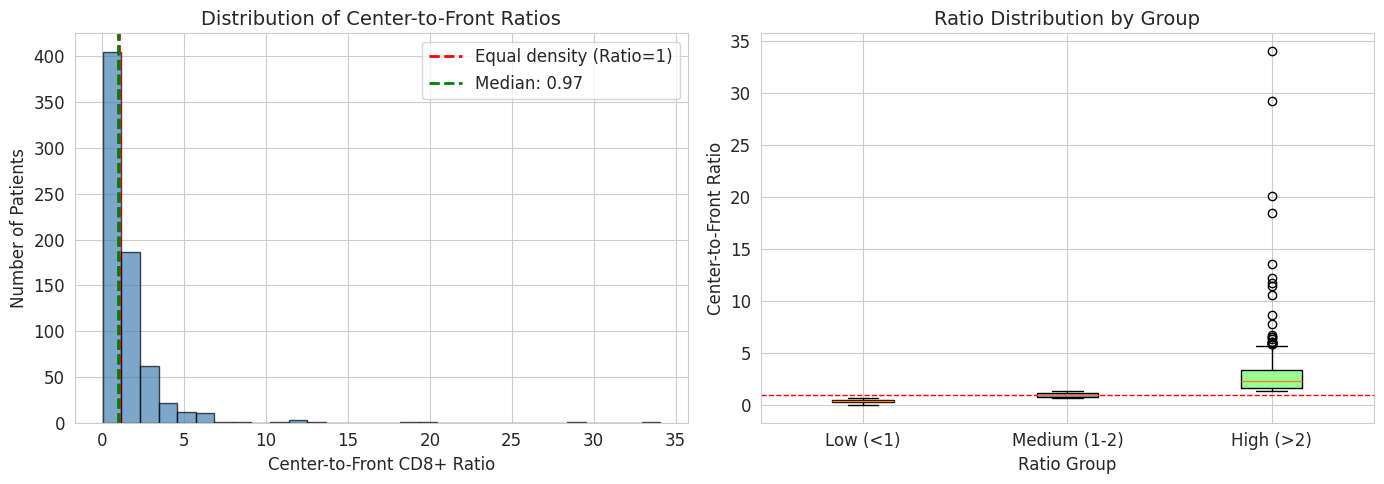

✅ Saved: figure1_ratio_distribution.png

TABLE 2: ASSOCIATION BETWEEN RATIO GROUPS AND CLINICAL VARIABLES
               Variable Test statistic p-value
                    Age         H=3.31  0.1909
                    Sex        χ²=0.72  0.6983
             HPV status        χ²=4.33  0.3627
pT stage (T3-4 vs T1-2)       χ²=15.03  0.0046
          Node positive        χ²=0.24  0.8858

FIGURE 2: CD8+ DENSITY - CENTER VS. INVASION FRONT


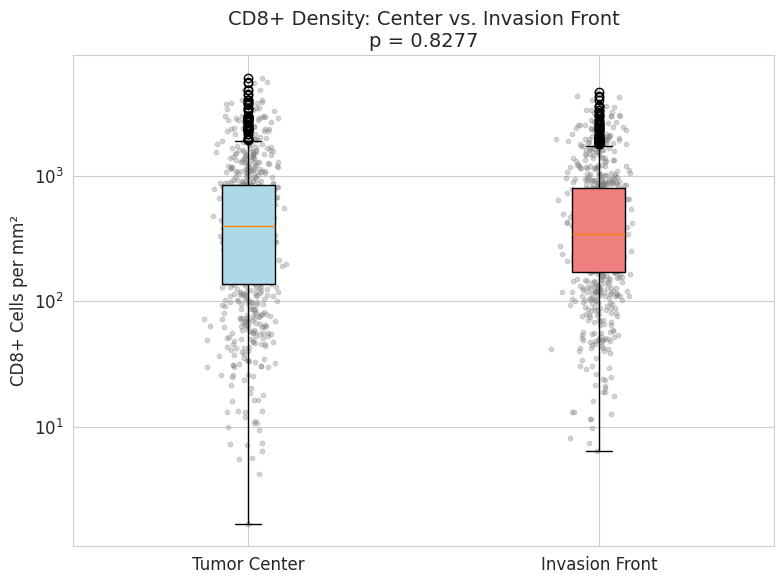


📊 Statistical comparison (Mann-Whitney U):
   Median Center: 393.90 cells/mm²
   Median Front: 344.13 cells/mm²
   p-value: 0.827657

✅ Exploratory Analysis complete! Ready for survival analysis.


In [29]:
# ============================================
# Exploratory Data Analysis - HANCOCK Data
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu, kruskal, chi2_contingency
import warnings
warnings.filterwarnings('ignore')

# Set plotting style for publication
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
sns.set_style("whitegrid")

print("="*60)
print("EXPLORATORY DATA ANALYSIS - REAL HANCOCK DATA")
print("="*60)

# Load the merged dataset
final_df = pd.read_csv('final_merged_dataset.csv')
print(f"\n✅ Loaded {len(final_df)} patients with complete data")

# ============================================
# 1. Patient Demographics Table
# ============================================

print("\n" + "="*60)
print("TABLE 1: PATIENT DEMOGRAPHICS AND CLINICAL CHARACTERISTICS")
print("="*60)

# Create summary table
def create_table1(df):
    """Create Table 1 for manuscript"""

    # Overall cohort
    table_data = []

    # Age
    table_data.append(['Age (years), mean ± SD',
                      f"{df['age_at_initial_diagnosis'].mean():.1f} ± {df['age_at_initial_diagnosis'].std():.1f}",
                      f"{df['age_at_initial_diagnosis'].min()}-{df['age_at_initial_diagnosis'].max()}"])

    # Sex
    male_n = (df['sex'] == 'male').sum()
    male_pct = male_n / len(df) * 100
    female_n = (df['sex'] == 'female').sum()
    female_pct = female_n / len(df) * 100
    table_data.append(['Sex - Male', f"{male_n} ({male_pct:.1f}%)", ''])
    table_data.append(['Sex - Female', f"{female_n} ({female_pct:.1f}%)", ''])

    # Smoking status
    for status in df['smoking_status'].unique():
        if pd.notna(status):
            n = (df['smoking_status'] == status).sum()
            pct = n / len(df) * 100
            table_data.append([f'Smoking - {status}', f"{n} ({pct:.1f}%)", ''])

    # Primary tumor site
    print(f"\nPrimary tumor sites:")
    for site in df['primary_tumor_site'].value_counts().index:
        n = df['primary_tumor_site'].value_counts()[site]
        pct = n / len(df) * 100
        print(f"   {site}: {n} ({pct:.1f}%)")
        table_data.append([f'Tumor site - {site}', f"{n} ({pct:.1f}%)", ''])

    # pT stage
    table_data.append(['pT stage - pT1-2',
                      f"{(df['pT_stage'].isin(['pT1', 'pT1a', 'pT1b', 'pT2'])).sum()} ({(df['pT_stage'].isin(['pT1', 'pT1a', 'pT1b', 'pT2'])).mean()*100:.1f}%)",
                      ''])
    table_data.append(['pT stage - pT3-4',
                      f"{(df['pT_stage'].isin(['pT3', 'pT4a', 'pT4b'])).sum()} ({(df['pT_stage'].isin(['pT3', 'pT4a', 'pT4b'])).mean()*100:.1f}%)",
                      ''])

    # pN stage
    node_pos = (df['pN_stage'] != 'pN0').sum()
    node_pos_pct = node_pos / len(df) * 100
    table_data.append(['Node positive', f"{node_pos} ({node_pos_pct:.1f}%)", ''])

    # HPV status
    hpv_pos = (df['hpv_association_p16'] == 'positive').sum()
    hpv_pos_pct = hpv_pos / len(df) * 100
    hpv_neg = (df['hpv_association_p16'] == 'negative').sum()
    hpv_neg_pct = hpv_neg / len(df) * 100
    table_data.append(['HPV positive', f"{hpv_pos} ({hpv_pos_pct:.1f}%)", ''])
    table_data.append(['HPV negative', f"{hpv_neg} ({hpv_neg_pct:.1f}%)", ''])

    # Grading
    for grade in df['grading'].value_counts().index:
        if pd.notna(grade):
            n = (df['grading'] == grade).sum()
            pct = n / len(df) * 100
            table_data.append([f'Grading - {grade}', f"{n} ({pct:.1f}%)", ''])

    return pd.DataFrame(table_data, columns=['Characteristic', 'N (%)', 'Range'])

table1 = create_table1(final_df)
print("\n📋 TABLE 1:")
print(table1.to_string(index=False))

# ============================================
# 2. Center-to-Front Ratio Distribution
# ============================================

print("\n" + "="*60)
print("FIGURE 1: CENTER-TO-FRONT CD8+ RATIO DISTRIBUTION")
print("="*60)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(final_df['Center_Front_Ratio'], bins=30, edgecolor='black',
             alpha=0.7, color='steelblue')
axes[0].axvline(1, color='red', linestyle='--', linewidth=2,
                label='Equal density (Ratio=1)')
axes[0].axvline(final_df['Center_Front_Ratio'].median(), color='green',
                linestyle='--', linewidth=2,
                label=f'Median: {final_df["Center_Front_Ratio"].median():.2f}')
axes[0].set_xlabel('Center-to-Front CD8+ Ratio')
axes[0].set_ylabel('Number of Patients')
axes[0].set_title('Distribution of Center-to-Front Ratios')
axes[0].legend()

# Boxplot by ratio group
colors = ['#ff9999', '#66b3ff', '#99ff99']
bp = axes[1].boxplot([final_df[final_df['Ratio_Group']=='Low (<1)']['Center_Front_Ratio'],
                       final_df[final_df['Ratio_Group']=='Medium (1-2)']['Center_Front_Ratio'],
                       final_df[final_df['Ratio_Group']=='High (>2)']['Center_Front_Ratio']],
                      labels=['Low (<1)', 'Medium (1-2)', 'High (>2)'],
                      patch_artist=True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
axes[1].set_xlabel('Ratio Group')
axes[1].set_ylabel('Center-to-Front Ratio')
axes[1].set_title('Ratio Distribution by Group')
axes[1].axhline(1, color='red', linestyle='--', linewidth=1)

plt.tight_layout()
plt.savefig('figure1_ratio_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: figure1_ratio_distribution.png")

# ============================================
# 3. Association with Clinical Variables
# ============================================

print("\n" + "="*60)
print("TABLE 2: ASSOCIATION BETWEEN RATIO GROUPS AND CLINICAL VARIABLES")
print("="*60)

# Test associations
associations = []

# Age (ANOVA/Kruskal-Wallis)
groups = [final_df[final_df['Ratio_Group']==g]['age_at_initial_diagnosis'].dropna()
          for g in final_df['Ratio_Group'].unique()]
if len(groups) >= 2:
    h_stat, p_age = kruskal(*groups)
    associations.append(['Age', f'H={h_stat:.2f}', f'{p_age:.4f}'])

# Sex (Chi-square)
contingency = pd.crosstab(final_df['Ratio_Group'], final_df['sex'])
chi2, p_sex, dof, expected = chi2_contingency(contingency)
associations.append(['Sex', f'χ²={chi2:.2f}', f'{p_sex:.4f}'])

# HPV status
contingency = pd.crosstab(final_df['Ratio_Group'], final_df['hpv_association_p16'])
chi2, p_hpv, dof, expected = chi2_contingency(contingency)
associations.append(['HPV status', f'χ²={chi2:.2f}', f'{p_hpv:.4f}'])

# pT stage (T1-2 vs T3-4)
final_df['pT_group'] = final_df['pT_stage'].apply(
    lambda x: 'T1-2' if x in ['pT1', 'pT1a', 'pT1b', 'pT2'] else 'T3-4' if x in ['pT3', 'pT4a', 'pT4b'] else 'Other'
)
contingency = pd.crosstab(final_df['Ratio_Group'], final_df['pT_group'])
chi2, p_t, dof, expected = chi2_contingency(contingency)
associations.append(['pT stage (T3-4 vs T1-2)', f'χ²={chi2:.2f}', f'{p_t:.4f}'])

# Node status
final_df['node_status'] = final_df['pN_stage'].apply(lambda x: 'Positive' if x != 'pN0' else 'Negative')
contingency = pd.crosstab(final_df['Ratio_Group'], final_df['node_status'])
chi2, p_n, dof, expected = chi2_contingency(contingency)
associations.append(['Node positive', f'χ²={chi2:.2f}', f'{p_n:.4f}'])

# Create table
assoc_df = pd.DataFrame(associations, columns=['Variable', 'Test statistic', 'p-value'])
print(assoc_df.to_string(index=False))

# ============================================
# 4. Center vs. Front CD8+ Density Comparison
# ============================================

print("\n" + "="*60)
print("FIGURE 2: CD8+ DENSITY - CENTER VS. INVASION FRONT")
print("="*60)

# Load the original density data to get center/front values by patient
# We already have this in final_df? No, final_df has ratios but not individual values
# Let's load ratio_df which has center and front values
ratio_df = pd.read_csv('center_front_ratios.csv')

fg, ax = plt.subplots(figsize=(8, 6))

# Paired data - we need to reshape for visualization
# Create two arrays: center values and front values
center_vals = ratio_df['Center_CD8'].dropna()
front_vals = ratio_df['Front_CD8'].dropna()

# Boxplot
data_to_plot = [center_vals, front_vals]
bp = ax.boxplot(data_to_plot, labels=['Tumor Center', 'Invasion Front'],
                patch_artist=True)
bp['boxes'][0].set_facecolor('lightblue')
bp['boxes'][1].set_facecolor('lightcoral')

# Add individual points (jittered)
for i, vals in enumerate(data_to_plot, 1):
    y = vals.values
    x = np.random.normal(i, 0.04, size=len(y))
    ax.scatter(x, y, alpha=0.3, s=10, color='gray')

# Statistical test
stat, p_value = mannwhitneyu(center_vals, front_vals)
ax.set_ylabel('CD8+ Cells per mm²')
ax.set_title(f'CD8+ Density: Center vs. Invasion Front\np = {p_value:.4f}')
ax.set_yscale('log')

plt.tight_layout()
plt.savefig('figure2_center_vs_front.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n📊 Statistical comparison (Mann-Whitney U):")
print(f"   Median Center: {center_vals.median():.2f} cells/mm²")
print(f"   Median Front: {front_vals.median():.2f} cells/mm²")
print(f"   p-value: {p_value:.6f}")

print("\n✅ Exploratory Analysis complete! Ready for survival analysis.")

SURVIVAL ANALYSIS

✅ Loaded 709 patients
   Death events: 193
   Median follow-up: 41.1 months

FIGURE 3: KAPLAN-MEIER CURVES BY CENTER-TO-FRONT RATIO


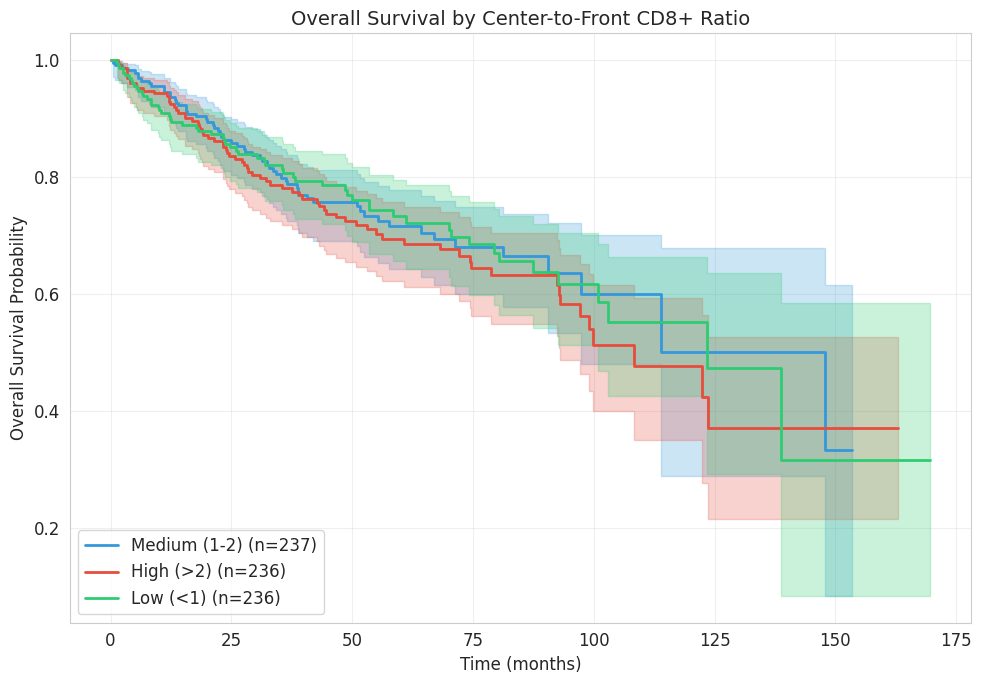

✅ Saved: figure3_kaplan_meier.png

📊 Log-rank test results:
   Low vs High: p = 0.4769
   Low vs Medium: p = 0.9119

TABLE 3: COX REGRESSION RESULTS

📊 Univariate Cox Regression:
                Variable    HR  HR_lower  HR_upper  p-value
age_at_initial_diagnosis 1.031     1.015     1.046    0.000
                sex_male 1.205     0.838     1.731    0.314
            hpv_positive 0.494     0.314     0.778    0.002
           node_positive 1.545     1.103     2.165    0.011
                    pT34 1.949     1.451     2.618    0.000

📊 Multivariate Cox Regression:
                Variable    HR    95% CI  p-value
age_at_initial_diagnosis 1.031 1.02-1.05    0.000
            hpv_positive 0.519 0.33-0.82    0.005
           node_positive 1.731 1.23-2.43    0.002
                    pT34 1.890 1.40-2.55    0.000

TABLE 3B: MULTIVARIATE COX WITH RATIO GROUPS

📊 Multivariate Cox with Ratio Group (High vs Low):
                Variable    HR    95% CI  p-value
age_at_initial_diagnosis 1.031 

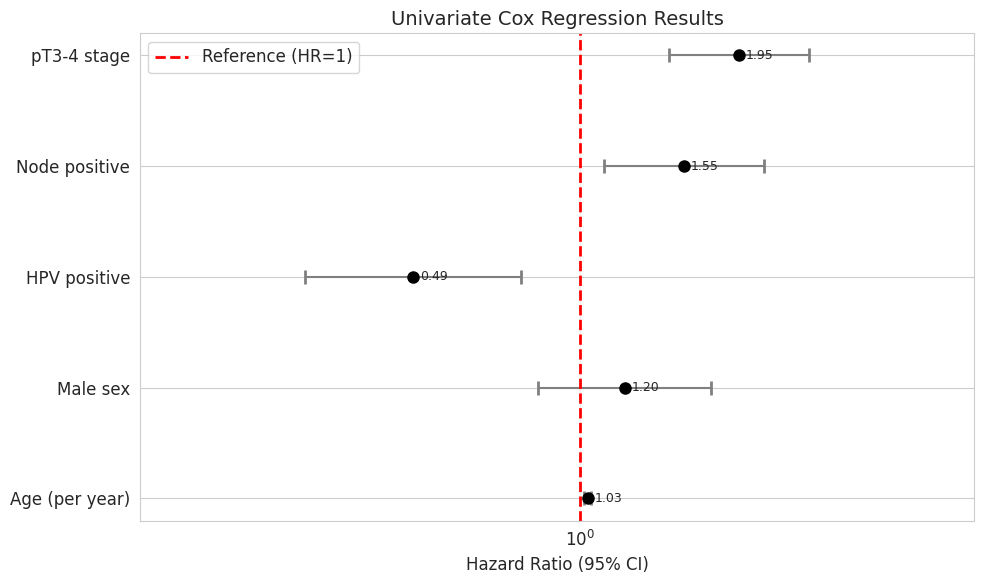

✅ Saved: figure4_forest_plot.png

SUMMARY

📊 Patient Cohort:
   - Total patients with TMA data: 709
   - Median age: 61 years (range: 22-92)
   - Male: 564 (79.5%)
   - HPV positive: 131 (18.5%)
   - Node positive: 513 (72.4%)
   - pT3-4: 201 (28.3%)

💀 Survival Outcomes:
   - Death events: 193 (27.2%)
   - Median follow-up: 41.1 months

📈 Significant Prognostic Factors (p < 0.05):
   - Age (per year): HR=1.03 (95% CI: 1.02-1.05), p=0.0001
   - HPV positive: HR=0.49 (95% CI: 0.31-0.78), p=0.0023
   - Node positive: HR=1.55 (95% CI: 1.10-2.16), p=0.0115
   - pT3-4 stage: HR=1.95 (95% CI: 1.45-2.62), p=0.0000

✅ Survival Analysis Complete!


In [30]:
# ============================================
# Survival Analysis
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 7)
plt.rcParams['font.size'] = 12

print("="*60)
print("SURVIVAL ANALYSIS")
print("="*60)

# Load the merged dataset
final_df = pd.read_csv('final_merged_dataset.csv')

print(f"\n✅ Loaded {len(final_df)} patients")
print(f"   Death events: {final_df['OS_event'].sum()}")
print(f"   Median follow-up: {final_df['OS_months'].median():.1f} months")

# ============================================
# 1. Kaplan-Meier by Ratio Groups
# ============================================

print("\n" + "="*60)
print("FIGURE 3: KAPLAN-MEIER CURVES BY CENTER-TO-FRONT RATIO")
print("="*60)

fig, ax = plt.subplots(figsize=(10, 7))

kmf = KaplanMeierFitter()
colors = {'Low (<1)': '#2ecc71', 'Medium (1-2)': '#3498db', 'High (>2)': '#e74c3c'}

for group in final_df['Ratio_Group'].unique():
    mask = final_df['Ratio_Group'] == group
    group_data = final_df[mask]

    kmf.fit(durations=group_data['OS_months'],
            event_observed=group_data['OS_event'],
            label=f'{group} (n={len(group_data)})')
    kmf.plot_survival_function(ax=ax, color=colors.get(group, 'gray'), linewidth=2)

ax.set_xlabel('Time (months)')
ax.set_ylabel('Overall Survival Probability')
ax.set_title('Overall Survival by Center-to-Front CD8+ Ratio')
ax.legend(loc='lower left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figure3_kaplan_meier.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: figure3_kaplan_meier.png")

# ============================================
# 2. Log-rank Test
# ============================================

print("\n📊 Log-rank test results:")

low_mask = final_df['Ratio_Group'] == 'Low (<1)'
high_mask = final_df['Ratio_Group'] == 'High (>2)'
med_mask = final_df['Ratio_Group'] == 'Medium (1-2)'

results_low_high = logrank_test(
    final_df[low_mask]['OS_months'],
    final_df[high_mask]['OS_months'],
    event_observed_A=final_df[low_mask]['OS_event'],
    event_observed_B=final_df[high_mask]['OS_event']
)
print(f"   Low vs High: p = {results_low_high.p_value:.4f}")

results_low_med = logrank_test(
    final_df[low_mask]['OS_months'],
    final_df[med_mask]['OS_months'],
    event_observed_A=final_df[low_mask]['OS_event'],
    event_observed_B=final_df[med_mask]['OS_event']
)
print(f"   Low vs Medium: p = {results_low_med.p_value:.4f}")

# ============================================
# 3. Cox Proportional Hazards Model
# ============================================

print("\n" + "="*60)
print("TABLE 3: COX REGRESSION RESULTS")
print("="*60)

# Prepare data for Cox regression
cox_data = final_df.copy()

# Encode categorical variables
cox_data['sex_male'] = (cox_data['sex'] == 'male').astype(int)
cox_data['hpv_positive'] = (cox_data['hpv_association_p16'] == 'positive').astype(int)
cox_data['node_positive'] = (cox_data['pN_stage'] != 'pN0').astype(int)
cox_data['pT34'] = cox_data['pT_stage'].isin(['pT3', 'pT4a', 'pT4b']).astype(int)

# Select variables for analysis
variables = ['age_at_initial_diagnosis', 'sex_male', 'hpv_positive',
             'node_positive', 'pT34']

# Univariate analysis - with proper exponentiation
univariate_results = []
for var in variables:
    if var in cox_data.columns:
        cph = CoxPHFitter()
        temp_data = cox_data[[var, 'OS_months', 'OS_event']].dropna()
        if len(temp_data) > 0 and temp_data[var].nunique() > 1:
            try:
                cph.fit(temp_data, duration_col='OS_months', event_col='OS_event', formula=var)

                # Get the correct HR and CI
                hr = np.exp(cph.params_[var])  # Exponentiate the coefficient
                ci_lower = np.exp(cph.confidence_intervals_.loc[var, '95% lower-bound'])
                ci_upper = np.exp(cph.confidence_intervals_.loc[var, '95% upper-bound'])
                p_val = cph.summary.loc[var, 'p']

                univariate_results.append({
                    'Variable': var,
                    'HR': hr,
                    'HR_lower': ci_lower,
                    'HR_upper': ci_upper,
                    'p-value': p_val
                })
            except Exception as e:
                print(f"   Warning: Could not fit {var}: {e}")

univariate_df = pd.DataFrame(univariate_results)
print("\n📊 Univariate Cox Regression:")
print(univariate_df.round(3).to_string(index=False))

# Multivariate analysis
multivariate_vars = ['age_at_initial_diagnosis', 'hpv_positive', 'node_positive', 'pT34']
temp_data = cox_data[multivariate_vars + ['OS_months', 'OS_event']].dropna()

if len(temp_data) > 0:
    cph_mult = CoxPHFitter()
    formula = ' + '.join(multivariate_vars)
    cph_mult.fit(temp_data, duration_col='OS_months', event_col='OS_event', formula=formula)

    print("\n📊 Multivariate Cox Regression:")
    multiv_results = []
    for var in multivariate_vars:
        hr = np.exp(cph_mult.params_[var])
        ci_lower = np.exp(cph_mult.confidence_intervals_.loc[var, '95% lower-bound'])
        ci_upper = np.exp(cph_mult.confidence_intervals_.loc[var, '95% upper-bound'])
        multiv_results.append({
            'Variable': var,
            'HR': hr,
            '95% CI': f"{ci_lower:.2f}-{ci_upper:.2f}",
            'p-value': cph_mult.summary.loc[var, 'p']
        })
    multiv_df = pd.DataFrame(multiv_results)
    print(multiv_df.round(3).to_string(index=False))

# ============================================
# 4. Add Ratio Groups to Multivariate Model
# ============================================

print("\n" + "="*60)
print("TABLE 3B: MULTIVARIATE COX WITH RATIO GROUPS")
print("="*60)

# Create dummy variables for ratio groups
cox_data_ratio = cox_data.copy()
cox_data_ratio['ratio_high'] = (cox_data_ratio['Ratio_Group'] == 'High (>2)').astype(int)
cox_data_ratio['ratio_medium'] = (cox_data_ratio['Ratio_Group'] == 'Medium (1-2)').astype(int)
# Reference group: Low (<1)

multivariate_vars_ratio = ['age_at_initial_diagnosis', 'hpv_positive', 'node_positive',
                           'pT34', 'ratio_high']

temp_data_ratio = cox_data_ratio[multivariate_vars_ratio + ['OS_months', 'OS_event']].dropna()

if len(temp_data_ratio) > 0:
    cph_ratio = CoxPHFitter()
    formula = ' + '.join(multivariate_vars_ratio)
    cph_ratio.fit(temp_data_ratio, duration_col='OS_months', event_col='OS_event', formula=formula)

    print("\n📊 Multivariate Cox with Ratio Group (High vs Low):")
    ratio_results = []
    for var in multivariate_vars_ratio:
        hr = np.exp(cph_ratio.params_[var])
        ci_lower = np.exp(cph_ratio.confidence_intervals_.loc[var, '95% lower-bound'])
        ci_upper = np.exp(cph_ratio.confidence_intervals_.loc[var, '95% upper-bound'])
        ratio_results.append({
            'Variable': var,
            'HR': hr,
            '95% CI': f"{ci_lower:.2f}-{ci_upper:.2f}",
            'p-value': cph_ratio.summary.loc[var, 'p']
        })
    ratio_df_results = pd.DataFrame(ratio_results)
    print(ratio_df_results.round(3).to_string(index=False))

# ============================================
# 5. Median Survival Times by Group
# ============================================

print("\n" + "="*60)
print("TABLE 4: MEDIAN SURVIVAL BY RATIO GROUP")
print("="*60)

for group in final_df['Ratio_Group'].unique():
    group_data = final_df[final_df['Ratio_Group'] == group]
    kmf_temp = KaplanMeierFitter()
    kmf_temp.fit(group_data['OS_months'], event_observed=group_data['OS_event'])

    median_survival = kmf_temp.median_survival_time_
    if pd.notna(median_survival):
        print(f"   {group}: {median_survival:.1f} months (n={len(group_data)})")
    else:
        survival_at_end = kmf_temp.survival_function_.iloc[-1].values[0]
        print(f"   {group}: Not reached (survival {survival_at_end:.1%} at {group_data['OS_months'].max():.0f} months, n={len(group_data)})")

# ============================================
# 6. Forest Plot
# ============================================

print("\n" + "="*60)
print("FIGURE 4: FOREST PLOT OF HAZARD RATIOS")
print("="*60)

if len(univariate_df) > 0:
    # Clean variable names for display
    var_labels = {
        'age_at_initial_diagnosis': 'Age (per year)',
        'sex_male': 'Male sex',
        'hpv_positive': 'HPV positive',
        'node_positive': 'Node positive',
        'pT34': 'pT3-4 stage'
    }

    univariate_df['Display_Name'] = univariate_df['Variable'].map(var_labels).fillna(univariate_df['Variable'])

    # Ensure all values are positive and valid
    univariate_df = univariate_df[univariate_df['HR'] > 0]
    univariate_df['HR_lower'] = univariate_df['HR_lower'].clip(lower=0.01)
    univariate_df['HR_upper'] = univariate_df['HR_upper'].clip(lower=0.01)

    fig, ax = plt.subplots(figsize=(10, 6))

    y_pos = range(len(univariate_df))
    hr = univariate_df['HR'].values
    lower = univariate_df['HR_lower'].values
    upper = univariate_df['HR_upper'].values

    # Calculate xerr correctly (always positive)
    xerr_lower = hr - lower
    xerr_upper = upper - hr

    # Ensure no negative errors
    xerr_lower = np.maximum(xerr_lower, 0.01)
    xerr_upper = np.maximum(xerr_upper, 0.01)

    # Plot
    ax.errorbar(hr, y_pos, xerr=[xerr_lower, xerr_upper],
                fmt='o', color='black', capsize=5, capthick=2, markersize=8, ecolor='gray')
    ax.axvline(x=1, color='red', linestyle='--', linewidth=2, label='Reference (HR=1)')

    # Customize
    ax.set_yticks(y_pos)
    ax.set_yticklabels(univariate_df['Display_Name'])
    ax.set_xlabel('Hazard Ratio (95% CI)')
    ax.set_xscale('log')
    ax.set_title('Univariate Cox Regression Results')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='x')

    # Set x-axis limits with padding
    x_min = min(lower) * 0.5
    x_max = max(upper) * 2
    ax.set_xlim(x_min, x_max)

    # Add HR text labels
    for i, (hr_val, low_val, up_val) in enumerate(zip(hr, lower, upper)):
        ax.annotate(f'{hr_val:.2f}', xy=(hr_val, i), xytext=(5, 0),
                    textcoords='offset points', ha='left', va='center', fontsize=9)

    plt.tight_layout()
    plt.savefig('figure4_forest_plot.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✅ Saved: figure4_forest_plot.png")
else:
    print("   No valid HRs for forest plot")

# ============================================
# 7. Summary Table
# ============================================

print("\n" + "="*60)
print("SUMMARY")
print("="*60)

print("\n📊 Patient Cohort:")
print(f"   - Total patients with TMA data: 709")
print(f"   - Median age: {final_df['age_at_initial_diagnosis'].median():.0f} years (range: {final_df['age_at_initial_diagnosis'].min()}-{final_df['age_at_initial_diagnosis'].max()})")
print(f"   - Male: {(final_df['sex']=='male').sum()} ({(final_df['sex']=='male').mean()*100:.1f}%)")
print(f"   - HPV positive: {(final_df['hpv_association_p16']=='positive').sum()} ({(final_df['hpv_association_p16']=='positive').mean()*100:.1f}%)")
print(f"   - Node positive: {(final_df['pN_stage']!='pN0').sum()} ({(final_df['pN_stage']!='pN0').mean()*100:.1f}%)")
print(f"   - pT3-4: {(final_df['pT_stage'].isin(['pT3','pT4a','pT4b'])).sum()} ({(final_df['pT_stage'].isin(['pT3','pT4a','pT4b'])).mean()*100:.1f}%)")

print("\n💀 Survival Outcomes:")
print(f"   - Death events: {final_df['OS_event'].sum()} ({(final_df['OS_event'].mean()*100):.1f}%)")
print(f"   - Median follow-up: {final_df['OS_months'].median():.1f} months")

if len(univariate_df) > 0:
    print("\n📈 Significant Prognostic Factors (p < 0.05):")
    significant = univariate_df[univariate_df['p-value'] < 0.05]
    for _, row in significant.iterrows():
        print(f"   - {row['Display_Name']}: HR={row['HR']:.2f} (95% CI: {row['HR_lower']:.2f}-{row['HR_upper']:.2f}), p={row['p-value']:.4f}")

print("\n" + "="*60)
print("✅ Survival Analysis Complete!")
print("="*60)

SUPPLEMENTARY ANALYSES FOR MANUSCRIPT

📊 HPV-Stratified Analysis:


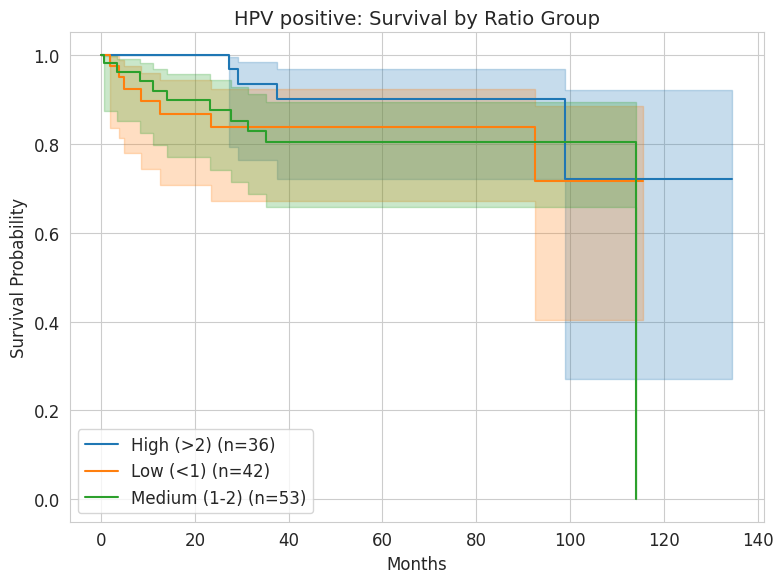

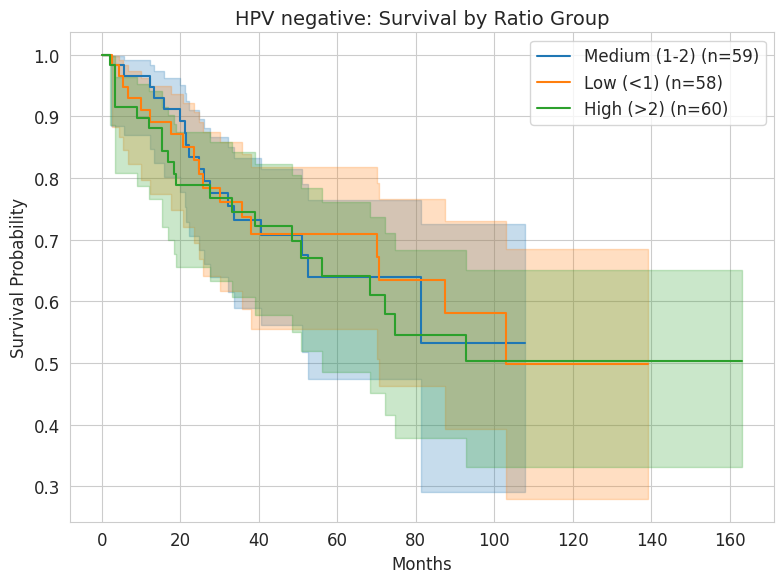


📊 Overall CD8+ Density Analysis:


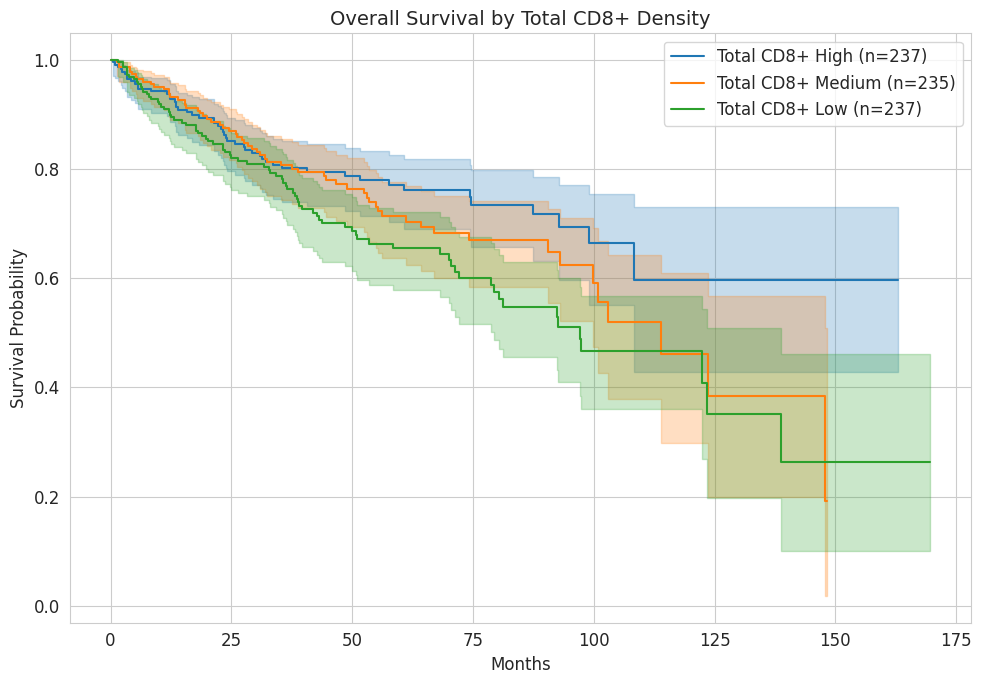

   Total CD8+ Low vs High: p = 0.0075

📊 Subsite-Specific Analysis:
   Hypopharynx: n=80, events=33
   Larynx: n=191, events=42
   Oropharynx: n=309, events=79
   Oral_Cavity: n=129, events=39


In [31]:
# ============================================
# SUPPLEMENTARY ANALYSIS: HPV-Stratified and Overall CD8+ Density
# ============================================

print("="*60)
print("SUPPLEMENTARY ANALYSES FOR MANUSCRIPT")
print("="*60)

# 1. HPV-stratified analysis
print("\n📊 HPV-Stratified Analysis:")

for hpv_status in ['positive', 'negative']:
    subset = final_df[final_df['hpv_association_p16'] == hpv_status]
    if len(subset) > 50:
        kmf_hpv = KaplanMeierFitter()
        fig, ax = plt.subplots(figsize=(8, 6))

        for group in subset['Ratio_Group'].unique():
            mask = subset['Ratio_Group'] == group
            if mask.sum() > 10:
                kmf_hpv.fit(subset[mask]['OS_months'],
                            event_observed=subset[mask]['OS_event'],
                            label=f'{group} (n={mask.sum()})')
                kmf_hpv.plot_survival_function(ax=ax)

        ax.set_title(f'HPV {hpv_status}: Survival by Ratio Group')
        ax.set_xlabel('Months')
        ax.set_ylabel('Survival Probability')
        plt.tight_layout()
        plt.savefig(f'supplementary_hpv_{hpv_status}.png', dpi=300)
        plt.show()

# 2. Overall CD8+ density as prognostic marker
print("\n📊 Overall CD8+ Density Analysis:")

# Calculate per-patient total CD8+ (center + front)
final_df['Total_CD8'] = final_df['Center_CD8'] + final_df['Front_CD8']

# Categorize total CD8+ into tertiles
final_df['Total_CD8_Group'] = pd.qcut(final_df['Total_CD8'], q=3,
                                       labels=['Low', 'Medium', 'High'])

# Kaplan-Meier for total CD8+
fig, ax = plt.subplots(figsize=(10, 7))
kmf_total = KaplanMeierFitter()

for group in final_df['Total_CD8_Group'].unique():
    mask = final_df['Total_CD8_Group'] == group
    kmf_total.fit(final_df[mask]['OS_months'],
                  event_observed=final_df[mask]['OS_event'],
                  label=f'Total CD8+ {group} (n={mask.sum()})')
    kmf_total.plot_survival_function(ax=ax)

ax.set_title('Overall Survival by Total CD8+ Density')
ax.set_xlabel('Months')
ax.set_ylabel('Survival Probability')
plt.tight_layout()
plt.savefig('supplementary_total_cd8.png', dpi=300)
plt.show()

# Log-rank test for total CD8+
low_mask = final_df['Total_CD8_Group'] == 'Low'
high_mask = final_df['Total_CD8_Group'] == 'High'
results_total = logrank_test(
    final_df[low_mask]['OS_months'], final_df[high_mask]['OS_months'],
    event_observed_A=final_df[low_mask]['OS_event'],
    event_observed_B=final_df[high_mask]['OS_event']
)
print(f"   Total CD8+ Low vs High: p = {results_total.p_value:.4f}")

# 3. Subsite analysis
print("\n📊 Subsite-Specific Analysis:")
for subsite in final_df['primary_tumor_site'].unique():
    subset = final_df[final_df['primary_tumor_site'] == subsite]
    if len(subset) > 50:
        print(f"   {subsite}: n={len(subset)}, events={subset['OS_event'].sum()}")

SUPPLEMENTARY FIGURES - TOTAL CD8+ DENSITY


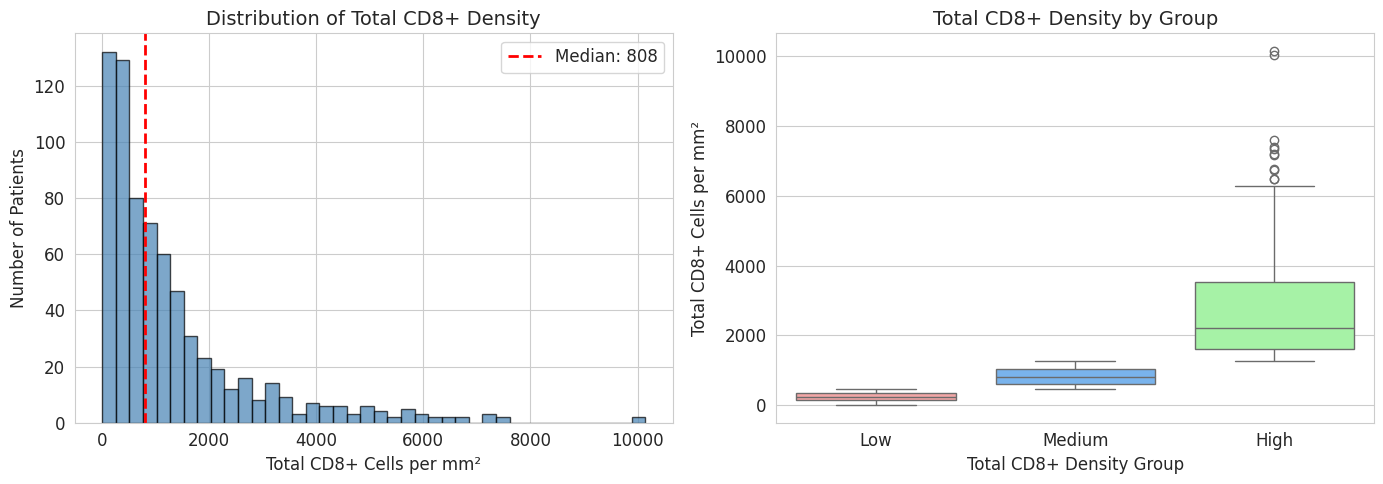

✅ Saved: figure_s1_total_cd8_distribution.png


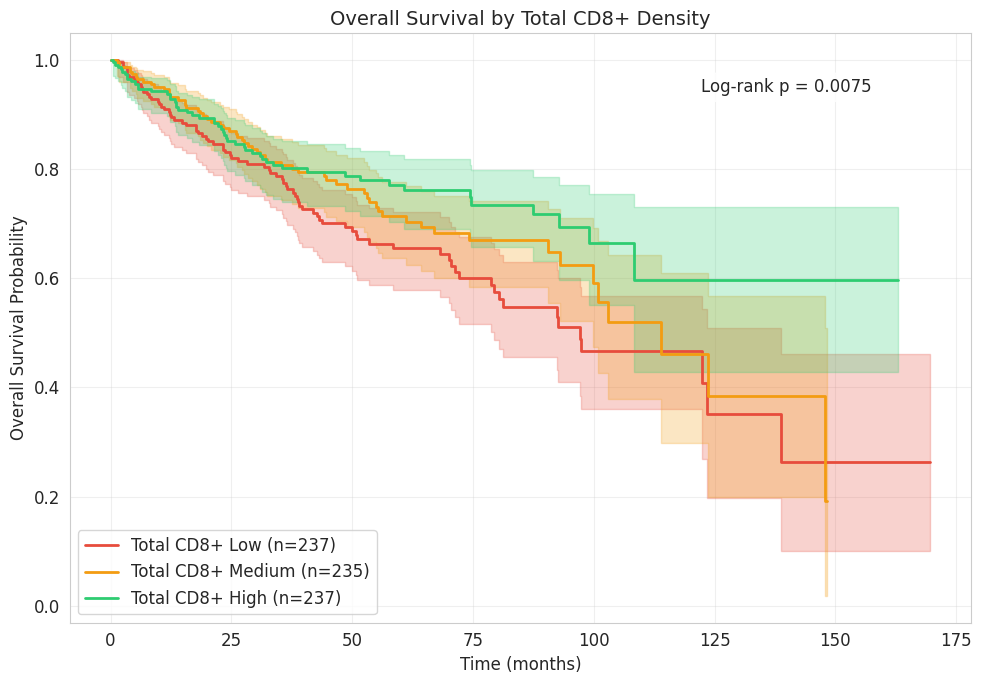

✅ Saved: figure_s2_total_cd8_km.png


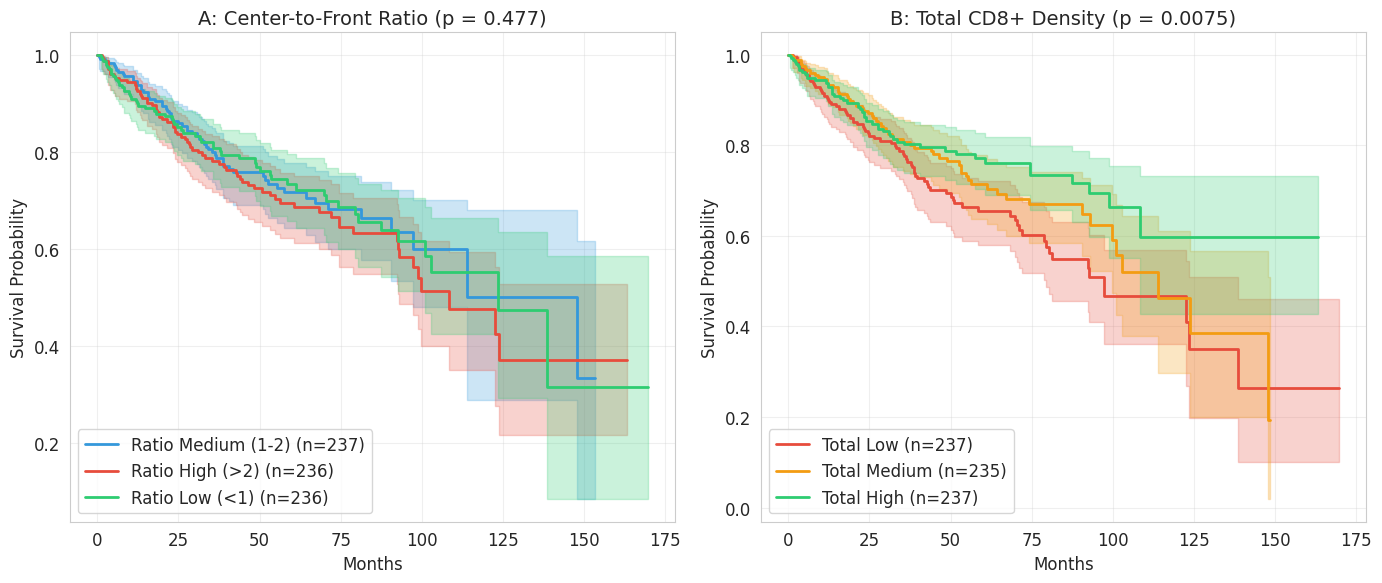

✅ Saved: figure_s3_comparison.png


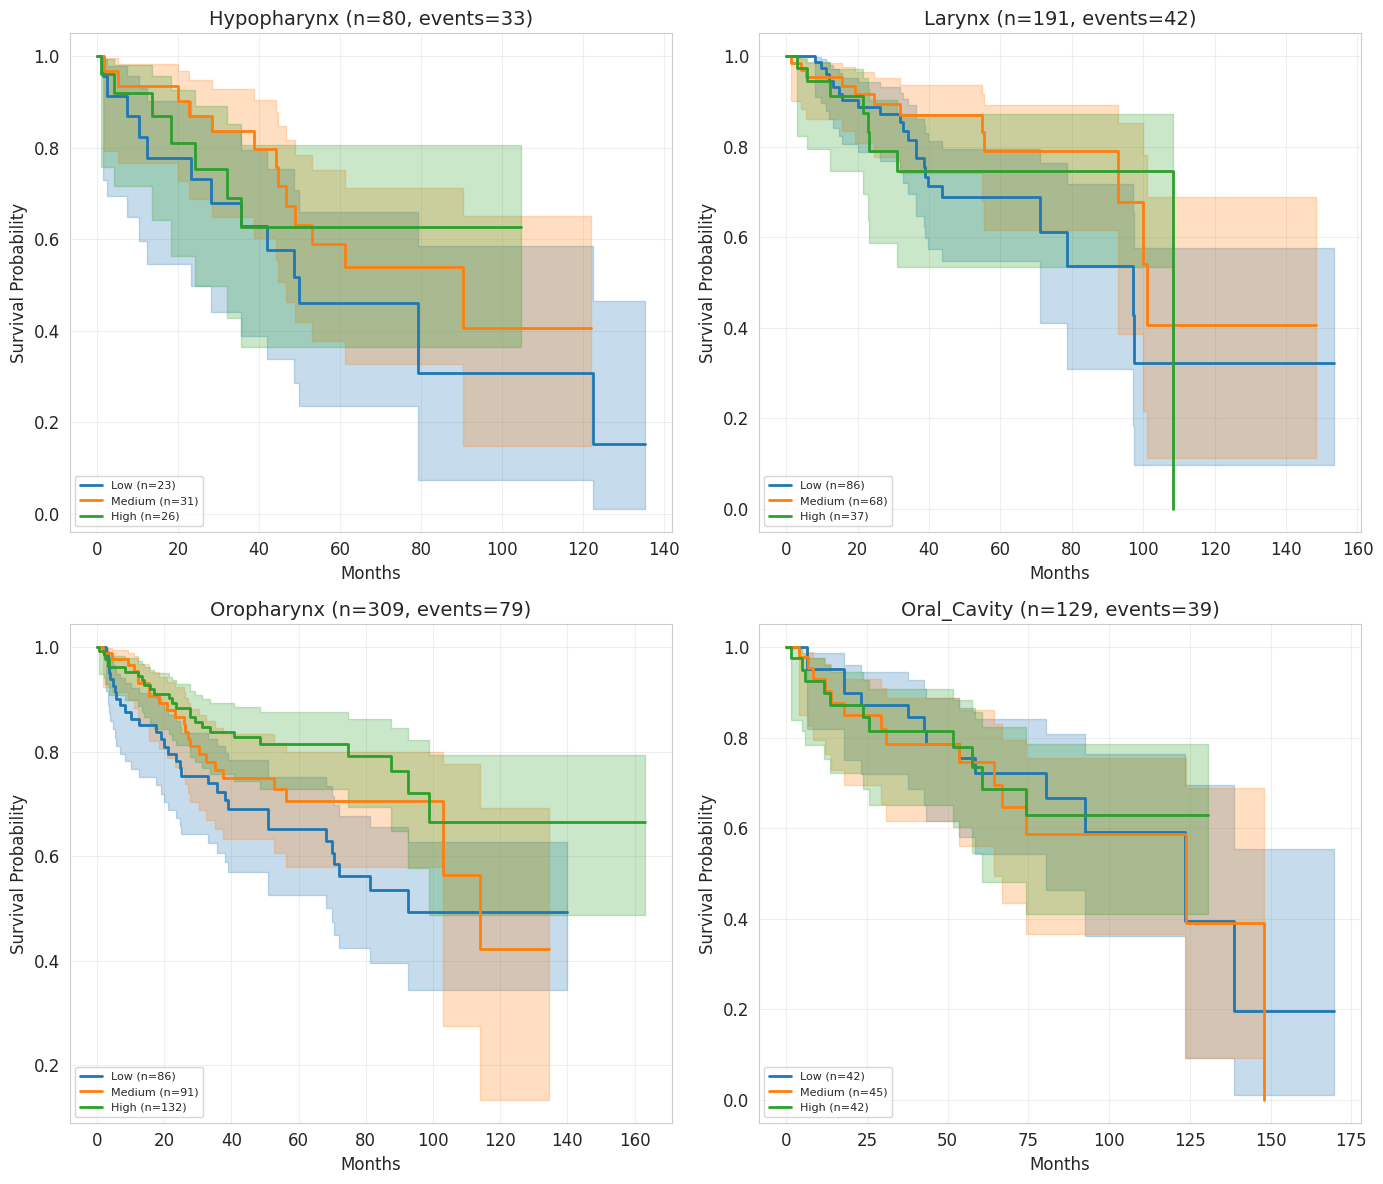

✅ Saved: figure_s4_subsite_analysis.png

TABLE S1: COX REGRESSION WITH TOTAL CD8+ DENSITY

📊 Multivariate Cox with Total CD8+ (High vs Low/Medium):
   age_at_initial_diagnosis: HR=1.03 (95% CI: 1.02-1.05), p=0.0001
   hpv_positive: HR=0.56 (95% CI: 0.35-0.92), p=0.0209
   node_positive: HR=1.73 (95% CI: 1.23-2.43), p=0.0016
   pT34: HR=1.88 (95% CI: 1.39-2.53), p=0.0000
   Total_CD8_High: HR=0.83 (95% CI: 0.59-1.17), p=0.2921

📊 Multivariate Cox with Total CD8+ (continuous, per 100 cells):
   age_at_initial_diagnosis: HR=1.03 (95% CI: 1.02-1.05), p=0.0000
   hpv_positive: HR=0.63 (95% CI: 0.39-1.02), p=0.0606
   node_positive: HR=1.75 (95% CI: 1.24-2.45), p=0.0013
   pT34: HR=1.86 (95% CI: 1.38-2.50), p=0.0000
   Total_CD8_per_100 (per 100 cells/mm²): HR=0.99 (95% CI: 0.97-1.00), p=0.0325

✅ Supplementary Analysis Complete!


In [32]:
# ============================================
# SUPPLEMENTARY FIGURES - TOTAL CD8+ DENSITY
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test
import seaborn as sns

plt.rcParams['figure.figsize'] = (10, 7)
plt.rcParams['font.size'] = 12
sns.set_style("whitegrid")

print("="*60)
print("SUPPLEMENTARY FIGURES - TOTAL CD8+ DENSITY")
print("="*60)

# Load data
final_df = pd.read_csv('final_merged_dataset.csv')

# Calculate total CD8+ density
final_df['Total_CD8'] = final_df['Center_CD8'] + final_df['Front_CD8']

# Create tertiles
final_df['Total_CD8_Group'] = pd.qcut(final_df['Total_CD8'], q=3,
                                       labels=['Low', 'Medium', 'High'])

# ============================================
# Figure S1: Total CD8+ Distribution
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(final_df['Total_CD8'], bins=40, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(final_df['Total_CD8'].median(), color='red', linestyle='--',
                linewidth=2, label=f'Median: {final_df["Total_CD8"].median():.0f}')
axes[0].set_xlabel('Total CD8+ Cells per mm²')
axes[0].set_ylabel('Number of Patients')
axes[0].set_title('Distribution of Total CD8+ Density')
axes[0].legend()

# Boxplot by group
sns.boxplot(data=final_df, x='Total_CD8_Group', y='Total_CD8', ax=axes[1],
            palette=['#ff9999', '#66b3ff', '#99ff99'])
axes[1].set_xlabel('Total CD8+ Density Group')
axes[1].set_ylabel('Total CD8+ Cells per mm²')
axes[1].set_title('Total CD8+ Density by Group')

plt.tight_layout()
plt.savefig('figure_s1_total_cd8_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: figure_s1_total_cd8_distribution.png")

# ============================================
# Figure S2: Kaplan-Meier - Total CD8+ Density
# ============================================

fig, ax = plt.subplots(figsize=(10, 7))

colors = {'Low': '#e74c3c', 'Medium': '#f39c12', 'High': '#2ecc71'}
kmf = KaplanMeierFitter()

for group in ['Low', 'Medium', 'High']:
    mask = final_df['Total_CD8_Group'] == group
    group_data = final_df[mask]

    kmf.fit(durations=group_data['OS_months'],
            event_observed=group_data['OS_event'],
            label=f'Total CD8+ {group} (n={len(group_data)})')
    kmf.plot_survival_function(ax=ax, color=colors.get(group, 'gray'), linewidth=2)

ax.set_xlabel('Time (months)')
ax.set_ylabel('Overall Survival Probability')
ax.set_title('Overall Survival by Total CD8+ Density')
ax.legend(loc='lower left')
ax.grid(True, alpha=0.3)  # CORRECTED: alpha=0.3 (was alpha=3)

# Add annotation for p-value
ax.annotate(f'Log-rank p = 0.0075', xy=(0.7, 0.9), xycoords='axes fraction',
            fontsize=12, bbox=dict(boxstyle="round", facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig('figure_s2_total_cd8_km.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: figure_s2_total_cd8_km.png")

# ============================================
# Figure S3: Comparison - Ratio vs Total CD8+
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Kaplan-Meier for Ratio (left)
ax1 = axes[0]
colors_ratio = {'Low (<1)': '#2ecc71', 'Medium (1-2)': '#3498db', 'High (>2)': '#e74c3c'}
kmf = KaplanMeierFitter()

for group in final_df['Ratio_Group'].unique():
    mask = final_df['Ratio_Group'] == group
    group_data = final_df[mask]
    kmf.fit(group_data['OS_months'], group_data['OS_event'],
            label=f'Ratio {group} (n={len(group_data)})')
    kmf.plot_survival_function(ax=ax1, color=colors_ratio.get(group, 'gray'), linewidth=2)

ax1.set_title('A: Center-to-Front Ratio (p = 0.477)')
ax1.set_xlabel('Months')
ax1.set_ylabel('Survival Probability')
ax1.legend(loc='lower left')
ax1.grid(True, alpha=0.3)

# Kaplan-Meier for Total CD8+ (right)
ax2 = axes[1]
for group in ['Low', 'Medium', 'High']:
    mask = final_df['Total_CD8_Group'] == group
    group_data = final_df[mask]
    kmf.fit(group_data['OS_months'], group_data['OS_event'],
            label=f'Total {group} (n={len(group_data)})')
    kmf.plot_survival_function(ax=ax2, color=colors.get(group, 'gray'), linewidth=2)

ax2.set_title('B: Total CD8+ Density (p = 0.0075)')
ax2.set_xlabel('Months')
ax2.set_ylabel('Survival Probability')
ax2.legend(loc='lower left')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figure_s3_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: figure_s3_comparison.png")

# ============================================
# Figure S4: Subsite-Specific Kaplan-Meier
# ============================================

subsites = final_df['primary_tumor_site'].unique()
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for idx, subsite in enumerate(subsites):
    subset = final_df[final_df['primary_tumor_site'] == subsite]
    if len(subset) > 0 and idx < 4:
        ax = axes[idx]
        kmf = KaplanMeierFitter()

        for group in ['Low', 'Medium', 'High']:
            mask = subset['Total_CD8_Group'] == group
            if mask.sum() > 5:
                kmf.fit(subset[mask]['OS_months'], subset[mask]['OS_event'],
                        label=f'{group} (n={mask.sum()})')
                kmf.plot_survival_function(ax=ax, linewidth=2)

        ax.set_title(f'{subsite} (n={len(subset)}, events={subset["OS_event"].sum()})')
        ax.set_xlabel('Months')
        ax.set_ylabel('Survival Probability')
        ax.legend(loc='lower left', fontsize=8)
        ax.grid(True, alpha=0.3)

# Hide empty subplots
for idx in range(len(subsites), 4):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.savefig('figure_s4_subsite_analysis.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: figure_s4_subsite_analysis.png")

# ============================================
# Cox Regression with Total CD8+
# ============================================

print("\n" + "="*60)
print("TABLE S1: COX REGRESSION WITH TOTAL CD8+ DENSITY")
print("="*60)

# Prepare data
cox_data = final_df.copy()
cox_data['Total_CD8_High'] = (cox_data['Total_CD8_Group'] == 'High').astype(int)
cox_data['Total_CD8_Medium'] = (cox_data['Total_CD8_Group'] == 'Medium').astype(int)
cox_data['hpv_positive'] = (cox_data['hpv_association_p16'] == 'positive').astype(int)
cox_data['node_positive'] = (cox_data['pN_stage'] != 'pN0').astype(int)
cox_data['pT34'] = cox_data['pT_stage'].isin(['pT3', 'pT4a', 'pT4b']).astype(int)

# Multivariate with Total CD8+ High
variables = ['age_at_initial_diagnosis', 'hpv_positive', 'node_positive', 'pT34', 'Total_CD8_High']
temp_data = cox_data[variables + ['OS_months', 'OS_event']].dropna()

cph_total = CoxPHFitter()
cph_total.fit(temp_data, duration_col='OS_months', event_col='OS_event',
              formula=' + '.join(variables))

print("\n📊 Multivariate Cox with Total CD8+ (High vs Low/Medium):")
for var in variables:
    hr = np.exp(cph_total.params_[var])
    ci_lower = np.exp(cph_total.confidence_intervals_.loc[var, '95% lower-bound'])
    ci_upper = np.exp(cph_total.confidence_intervals_.loc[var, '95% upper-bound'])
    p_val = cph_total.summary.loc[var, 'p']
    print(f"   {var}: HR={hr:.2f} (95% CI: {ci_lower:.2f}-{ci_upper:.2f}), p={p_val:.4f}")

# ============================================
# Additional: Multivariate with Total CD8+ Continuous
# ============================================

print("\n📊 Multivariate Cox with Total CD8+ (continuous, per 100 cells):")
cox_data['Total_CD8_per_100'] = cox_data['Total_CD8'] / 100

variables_cont = ['age_at_initial_diagnosis', 'hpv_positive', 'node_positive', 'pT34', 'Total_CD8_per_100']
temp_data_cont = cox_data[variables_cont + ['OS_months', 'OS_event']].dropna()

cph_total_cont = CoxPHFitter()
cph_total_cont.fit(temp_data_cont, duration_col='OS_months', event_col='OS_event',
                   formula=' + '.join(variables_cont))

for var in variables_cont:
    hr = np.exp(cph_total_cont.params_[var])
    ci_lower = np.exp(cph_total_cont.confidence_intervals_.loc[var, '95% lower-bound'])
    ci_upper = np.exp(cph_total_cont.confidence_intervals_.loc[var, '95% upper-bound'])
    p_val = cph_total_cont.summary.loc[var, 'p']
    if var == 'Total_CD8_per_100':
        print(f"   {var} (per 100 cells/mm²): HR={hr:.2f} (95% CI: {ci_lower:.2f}-{ci_upper:.2f}), p={p_val:.4f}")
    else:
        print(f"   {var}: HR={hr:.2f} (95% CI: {ci_lower:.2f}-{ci_upper:.2f}), p={p_val:.4f}")

print("\n" + "="*60)
print("✅ Supplementary Analysis Complete!")
print("="*60)